# Activitat 2: Streaming - adquisició i anàlisi de dades

# Introducció

En aquesta activitat, explorarem dues de les tecnologies més populars utilitzades per a l'adquisició i anàlisi de dades en temps real: Apache Kafka i Apache Spark Streaming. A través d'una sèrie d'exercicis, aprendreu els conceptes bàsics d'aquestes tecnologies i com usar-les per processar dades en temps real.

## Estructura

Hem dividit aquesta activitat en tres parts:

1.  **Introducció a Apache Kafka:** En aquesta primera part, aprendreu els conceptes bàsics d'Apache Kafka, 
    els seus principals components i com interactuar amb ells utilitzant la interfície de línia de comandes.
2.  **Ingesta de dades amb Apache Kafka:** En aquesta segona part, aprendreu a utilitzar Apache Kafka per ingerir
    dades des d'un productor i consumir-les des d'un consumidor.
3.  **Processament de dades en temps real amb Apache Spark Streaming:** En aquesta tercera part, aprendreu a usar 
    Apache Spark Streaming per processar dades en temps real provinents d'Apache Kafka.
    

## Notes importants:

- L'activitat s'ha de realitzar en **grups de 2 membres**. 
  Assegura't de saber qui és el teu company abans de començar l'activitat.
- Tot i que és possible completar les activitats directament en aquest quadern, **desaconsellamos fer-ho** a causa de possibles problemes de rendiment del servidor. Veuràs que cada activitat està continguda en la seva pròpia cel·la, cosa que et permetrà copiar-la fàcilment a un fitxer Python. Aquest fitxer pot ser **executat al servidor utilitzant el terminal de Jupyterlab, SSH o VSCode**. Un cop hagis executat i provat l'script amb èxit, simplement copia'l de nou a la cel·la corresponent del quadern. Aquest enfocament garanteix una execució més fluida i una millor gestió dels recursos del servidor.
- En alguns exercicis, necessitaràs fer **captures de pantalla per justificar les teves respostes**. 
  Pots capturar imatges utilitzant les eines del sistema operatiu que estiguis usant: "Retalls" a         Windows, "Imprimir pantalla", `Ctrl+C` en seleccionar una imatge, etc. 
  Un cop capturades, pots enganxar les imatges directament a les cel·les de resposta usant `Ctrl+V` o el menú     contextual que apareix en fer clic dret, que permetrà enganxar la imatge del porta-retalls. 
  Per visualitzar la imatge, has d'executar la cel·la.
- **Has d'utilitzar únicament les biblioteques proporcionades, tret que s'indiqui el contrari.**
- Si us plau, no canviïs el nom del quadern ni el tipus de les cel·les.

# Part I: Introducció a Apache Kafka (1.2 punts)

[Kafka](https://kafka.apache.org) és una plataforma distribuïda per gestionar 
esdeveniments en streaming que ens permet llegir, escriure i processar esdeveniments 
(registres o missatges, segons la terminologia de Kafka) distribuïts al llarg d'un clúster.

Començarem l'activitat creant un tema anomenat `activity2<usuari>`
al servei de Kafka del nostre clúster (substitueix `<usuari>` pel teu nom d'usuari). 
Un tema és una col·lecció ordenada d'esdeveniments que s'emmagatzema de forma persistent, generalment en disc,
i es distribueix i replica. Kafka tracta cada tema en cada partició com un registre 
(un conjunt ordenat de missatges). Cada missatge en una partició té un desplaçament únic, 
i aquests missatges tenen un període de retenció predeterminat de 7 dies (604.800.000 ms), 
tot i que pots modificar-lo en el moment de la creació del tema.

El broker de Kafka és `eimtcld3node1`, accessible al port estàndard 9092.

### Exercici 1: Crear un tema amb Kafka (0.15 punts)

Crea un tema de Kafka anomenat `activity2<usuari>` al nostre clúster amb un 
factor de replicació d'1 i una única partició, cosa que significa que usarem 
un sol node per emmagatzemar els missatges que rep Kafka. 
A més, especifica que els missatges només s'emmagatzemin durant 3 hores al tema.

**Per fer-ho, utilitzem el command kafka-topics.sh [[1]](https://www.gravitee.io/blog/guide-on-kafka-topic-creation-setup-to-automation) [[2]](https://coralogix.com/blog/create-kafka-topics-in-3-easy-steps/) [[3]](https://towardsdev.com/part-three-apache-kafka-basic-cli-commands-392f35d3e505) amb les especificacions demanades:**
- **el nostre cluster:`eimtcld3node1`, accessible al port estàndard 9092**
- **tema: `activity2aestanymac`**
- **numero de particions: 1**
- **numero de replicació: 1**
- **retenció (en ms): 3 hores = 60x60x3x1000 = 10800 s = 10800000 ms [[4]](https://community.cloudera.com/t5/Support-Questions/How-to-define-topic-retention-with-kafka/td-p/222671)**

**El codi s'ha executat directament a la terminal de Jupyterlab de la següent manera:**

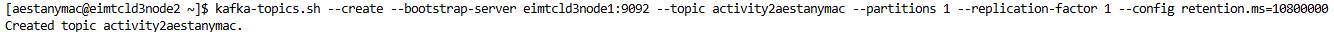

### Exercici 2: Llista els temes de Kafka (0.15 punts)

Consulta el *tema* que acabes de crear i mostra'l.

**Per tal de consultar el tema creat, podem llistar-los de la següent manera [[3]](https://towardsdev.com/part-three-apache-kafka-basic-cli-commands-392f35d3e505) [[5]](https://www.baeldung.com/ops/kafka-list-topics):**

**La consulta anterior s'ha executat a la terminal, on podem veure que entre els temes llistats hi ha el tema activity2aestanymac creat:**

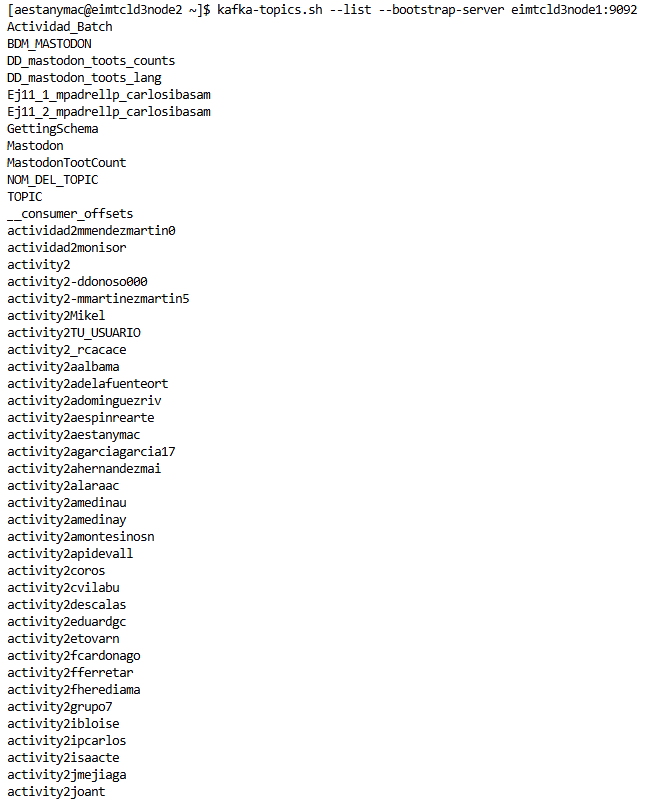

### Exercici 3: Esborra el tema de Kafka (0.15 punts)

Esborra el *tema* que vas crear a l'Exercici 1

**Per fer-ho utilitzem delete [[3]](https://towardsdev.com/part-three-apache-kafka-basic-cli-commands-392f35d3e505) [[6]](https://stackoverflow.com/questions/76944799/how-to-delete-all-kafka-topics-at-once-using-kafka-topics-sh-on-macos) [[7]](https://www.confluent.io/blog/delete-kafka-topic/):**

!kafka-topics.sh \ # [3, 6-7]
    --delete \
    --bootstrap-server eimtcld3node1:9092 \
    --topic activity2aestanymac

**Amb aquest command, podem esborrar el topic creat. Posteriorment mirem amb la comanda de l'exercici 2 si s'ha esborrat l'activitat, i podem veure que efectivament aquesta ja no apareix:**

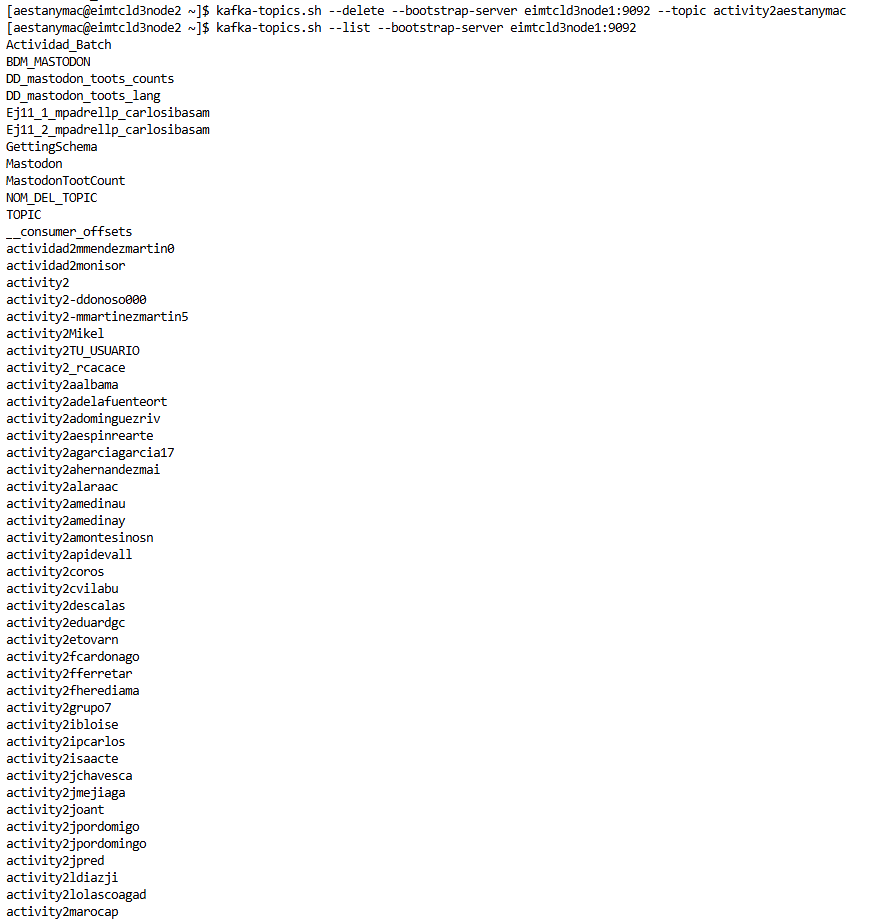

### Exercici 4: Descriu el tema de Kafka (0.15 punts)

Crea el *tema* de nou tal com vas fer a l'Exercici 1 i utilitza la línia de comandes de kafka per descriure'l.

**Després de tornar a crear el amb el command de l'exercici 1:**

**El describim amb "describe" [[3]](https://towardsdev.com/part-three-apache-kafka-basic-cli-commands-392f35d3e505):**

**Així, podem veure el resultat de l'execució a la terminal en la següent imatge:**

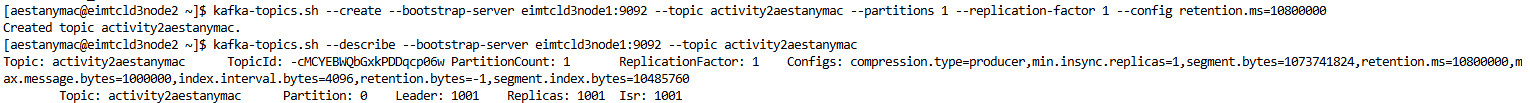

**Així, veiem que tenim només una partició (la 0) i una sola rèplica, situada al broker 1001, que també actua com a líder de la partició. L’ISR (In-Sync Replicas) coincideix amb aquest broker, indicant que la rèplica està correctament sincronitzada.**

### Exercici 5: Crea un productor a Kafka (0.3 punts)

Crearem un esdeveniment al tema. Recorda que aquesta comanda <b>s'ha d'executar
des del terminal per interactuar</b>. Recorda usar `CTRL+c` quan hagis acabat d'enviar els missatges.

**Per fer-ho, seguim l'exemple de [[8]](https://kafka.apache.org/quickstart/):**

**A la terminal hem executat la comanda anterior, que ens ha permés enviar enviar els missatges "Primer esdeveniment" i "Segon esdeveniment" al tema activity2aestanymac creat anteriorment:**

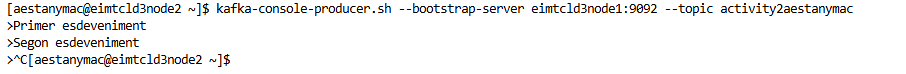

**Finalment, hem sortit amb ctrl+c.**

### Exercici 6: Crea un consumidor a Kafka (0.3 punts)

Finalment, se't demana consultar els missatges enviats a través del terminal 
utilitzant el consumidor incorporat de Kafka per al tema. Específicament, has d'executar 
un consumidor connectant-te als diferents brokers existents i especificant el tema 
i la partició als quals s'han enviat els missatges. Pots obrir dos terminals 
i verificar que els missatges enviats amb el productor al broker poden ser 
visualitzats amb el consumidor de consola.

**Seguint amb l'exemple de [[8]](https://kafka.apache.org/quickstart/) o altres [[9]](https://medium.com/@sirajul.anik/apache-kafka-understanding-how-to-produce-and-consume-messages-9744c612f40f), a traves de la terminal executem el consumidor de Kafka per tal de llegir els missatges que hem enviat al tema. Per fer-ho, cal especificar el tema i la partició.**

**Així, el resultat és:**

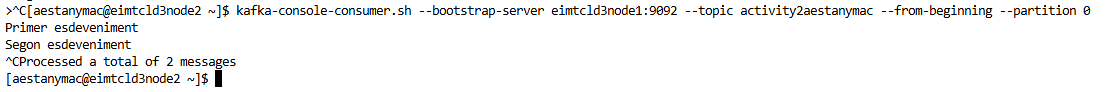

**Per comprovar-ho, obrim 2 terminals, una amb el productor i un altre amb el producer, de manera que deixarem les consoles obertes. Així, hauríem de veure com els missatges en ser enviats pel productor són rebuts en temps real pel consumidor:**

**Des d'una terminal, el productor envia:**

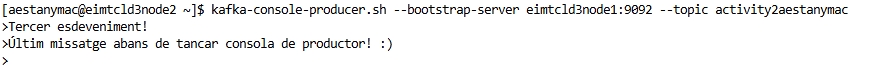

**I el consumidor en temps real va rebent els missatges en la segona terminal:**

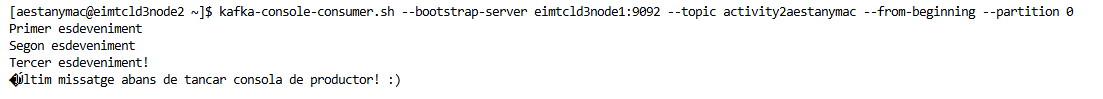

**Finalment tanquem les dues consoles amb ctrl+c.**

# Part II: Ingesta de dades amb Apache Kafka (1 punt)

Per automatitzar la generació i el consum de dades, és comú treballar 
amb un llenguatge de programació com Python, en lloc de fer-ho directament en Bash. 
En les preguntes següents, explorarem la funcionalitat de Kafka utilitzant Python amb la biblioteca per defecte, que **NO HAS D'INSTAL·LAR, ja que ja està disponible en la versió correcta**. 
Tota la documentació associada amb l'API proporcionada la pots trobar a 
[Kafka](https://kafka-python.readthedocs.io/en/master/). Començarem amb el que 
ja hem cobert: escriure en el tema de Kafka.
Per a això, configurarem el [Kafka
producer](https://kafka-python.readthedocs.io/en/master/apidoc/KafkaProducer.html)
que inserirà valors numèrics en un tema de Kafka cada 3 segons. 
Mentre el productor escriu, procedirem a llegir els missatges a la pregunta 8.

### Exercici 7: Escriu un tema a Kafka (0.3 punts)


Se't demana escriure una seqüència numèrica de 250 nombres (de l'1 al 250) 
en el tema de Kafka activity2<usuari> que acabem de crear. Cada un dels 
missatges escrits en el tema ha de contenir informació sobre el tema on s'escriuen, 
una clau i el valor binari del nombre a escriure (per exemple, value=b'287'). 
És essencial revisar l'API associada amb el 
[Kafka producer](https://kafka-python.readthedocs.io/en/master/apidoc/KafkaProducer.html) 
per completar aquests exercicis.

Per guiar-te en l'exercici, et proporcionem una plantilla que pots usar per completar-lo. Has de completar les parts que falten del codi a la cel·la de codi a continuació.
   

In [3]:
from kafka import KafkaProducer
import numpy as np
<FILL_IN>
for i in range(1,250):
    <FILL_IN>
producer.flush()

SyntaxError: invalid syntax (1730255302.py, line 3)

**NOTA: no podem modificar la cel·la anterior (però se'ns demana no borrar cel·les), per això treballem en la següent.**

**Seguint amb alguns exemples trobats [[10]](https://www.svix.com/guides/kafka/python-kafka-producer/) [[11]](https://kafka-python.readthedocs.io/en/master/apidoc/KafkaProducer.html) [[12]](https://stackoverflow.com/questions/39489649/encoding-formatting-issues-with-python-kafka-library) [[13]](https://kafka-python.readthedocs.io/en/master/), primer creem el productor, fent que apunti al broker correcte. Després, mitjançant `producer.send` enviem els missatges on codifiquem el valor del nombre a enviar mitjançant `encode('utf-8')`(que després haurem de descodificar) sota la clau (o key) "number" (també codificada en bytes).**

**NOTA: en l'enunciat es menciona que els missatges cal enviar-los cada 3 segons. Tanmateix, en les instruccions de la PAC se'ns comenta que no podem utilitzar més llibreries de les que ja tenim si no s'especifica. Si poguessim, importariem la llibreria `time` i mitjançant `time.sleep(3)` podriem fer que el productor enviés missatges cada 3 segons.**

In [1]:
from kafka import KafkaProducer
import numpy as np
# import time

producer = KafkaProducer(bootstrap_servers='eimtcld3node1:9092') # creem el productor [10]

for i in range(1, 250):
    # format del producer.send: send(topic, value=None, key=None, headers=None, partition=None, timestamp_ms=None) [11]
    producer.send('activity2aestanymac', key=b'number', value=str(i).encode('utf-8'))  # nomes enten bytes, així que cal passar key i value en bytes
    # time.sleep(3) # per enviar 1 missatge cada 3 segons
producer.flush()
producer.close()

### Exercici 8: Llegir un tema de Kafka (0.7 punts)

Usant la biblioteca de Python per a Kafka, 
[Kafka](https://kafka-python.readthedocs.io/en/master/),
llegeix els missatges enviats a l'exercici 7, mostrant només els valors, 
no les altres propietats del missatge. És important revisar l'ús de Kafka en 
([Python](https://kafka-python.readthedocs.io/en/master/usage.html))
i els paràmetres del consumidor de 
[Kafka
consumer](https://kafka-python.readthedocs.io/en/master/apidoc/KafkaConsumer.html).

Com en l'exercici anterior, aquí et proporcionem una plantilla que pots usar per completar l'exercici. Has de completar les parts que falten del codi.

In [2]:
from kafka import KafkaConsumer
<FILL_IN>
for message in consumer:
    <FILL_IN>

SyntaxError: invalid syntax (101348245.py, line 2)

**Seguint la plantilla proporcionada, primer cal crear el consumidor, que fem que apunti al tema, al broker correcte, i que mostri tots els missatges des del principi (si no posem `earliest` i en canvi ho deixem en el format per defecte `latest`, aleshores només mostrarà els missatges nous, mentre que si ja s'han enviat, com és aquest cas, no els veurem). També cal descodificar els missatges, tal com mencionen a [[14]](https://kafka-python.readthedocs.io/en/master/usage.html#kafkaconsumer).**

**A més a més, també hem vist que Kafka emmagatzema els missatges de manera acumulativa (append-only), de manera que cada execució del productor afegeix nous esdeveniments al final del topic sense sobreescriure els anteriors, de manera que podem acabar amb diverses sèries de 1-250 segons el nobre de vegades que hem executat la cel·la d'enviament de missatges del productor.**

**El consumidor, com podem veure, es queda "obert" esperant nous missatges (de la mateixa manera que hem pogut veure en la Part I enviant missatges entre productor i consumidor entre les dues terminals que teniem obertes). Així, la manera d'aturar l'execució del consumidor és aturant el kernel un cop hem rebut tots els missatges que el productor ha enviat (nombres de l'1 al 250).**

In [3]:
from kafka import KafkaConsumer

consumer = KafkaConsumer('activity2aestanymac', bootstrap_servers='eimtcld3node1:9092', auto_offset_reset='earliest', consumer_timeout_ms=5000) # cal dir-li que començi pel principi, sinó només mostrarà els nous

for message in consumer:
    print(message.value.decode('utf-8')) # [14] cal descodificar

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249


##### Part III: Processament de dades en temps real amb Apache Spark Streaming (6.5 punts)

En aquesta part de l'activitat, ens centrarem en l'ús d'Apache Spark per processar dades en temps real. Aquí, utilitzarem:

-   [Spark Streaming](https://downloads.apache.org/spark/docs/3.3.0/streaming-programming-guide.html):
    Spark Streaming és un motor de processament de fluxos escalable i tolerant a fallades, 
    construït sobre Apache Spark. Permet el processament de dades en temps real amb alta capacitat de               rendiment i baixa latència. Amb Spark Streaming, pots realitzar anàlisis en temps real, 
    aprenentatge automàtic i processament de grafs sobre dades en streaming.
-   [Spark Structured Streaming](https://downloads.apache.org/spark/docs/3.3.0/structured-streaming-programming-guide.html):
    Structured Streaming és una API d'alt nivell per al processament de fluxos en Spark. Proporciona una             interfície declarativa i similar a SQL per processar dades d'streaming estructurades.
    Amb Structured Streaming, pots escriure consultes d'streaming que s'integren de manera 
    fluida amb el processament per lots, cosa que et permet construir pipelines de processament 
    de dades d'extrem a extrem.
   

En aquesta part de l'activitat, ens centrarem en la xarxa social Mastodon per processar les seves dades en streaming. És una bona idea familiaritzar-se amb l'estructura JSON d'un "toot" (consulta l'enllaç [Mastodon\'s API
webpage](https://docs.joinmastodon.org/entities/Status/)), per facilitar la comprensió dels diferents exercicis que proposem.

**Notes importants:**

-   Tingues en compte que, en usar la versió 3.3.0 d'Apache Spark, pot haver-hi diferències en l'API i altres característiques en comparació amb les versions més recents. Assegura't de consultar la documentació específica per a aquesta versió quan necessitis més detalls.

-   Recorda adjuntar una captura de pantalla del resultat de l'execució de cada exercici en aquesta part de l'activitat.

### Exercici 10: Spark Streaming (2.7 punts)

En aquest exercici, analitzaràs l'activitat a Mastodon comptant els toots en una finestra de temps. Comptar és una de les operacions fonamentals a Spark, i en aquesta activitat, aprofitarem la biblioteca de Spark Streaming per millorar les nostres capacitats de recompte.

#### Exercici 10.1: Counting in Windows (0.4 punts)

Com sabràs, la biblioteca Spark Streaming **processa les dades utilitzant el concepte de time windows**, 
agrupant els elements de dades segons el temps en què van ser rebuts. Aquest enfocament 
permet el processament per lots de dades d'streaming, habilitant anàlisis **sobre intervals de temps diferents**. Veuràs que la sintaxi per realitzar operacions sobre els RDDs dins d'aquestes finestres de temps és **pràcticament equivalent a les operacions estàndard de RDD** que ja coneixes.

Completa el codi a continuació per obtenir **el nombre de toots originals publicats cada 10 segons**. Exclou els retweets del teu recompte. Pot ser que necessitis consultar [Mastodon
API](https://docs.joinmastodon.org/entities/Status/) per entendre com estan estructurats els toots.

**Primer es crea un SparkContext i un StreamingContext amb un interval de batch de 10 segons, que defineix cada quant es processaran les dades entrants. El flux de dades s’obté mitjançant socketTextStream, que escolta missatges enviats a través d’un port local (9999). Cada missatge representa un toot en format JSON.**

**Un cop rebudes les dades, es processen en diverses etapes:**

**- Es converteix cada línia de text a un objecte JSON amb json.loads.**

**- Es filtren els missatges per excloure els que són reblogs, és a dir, es comptabilitzen només els toots originals (l'esquema de toots s'ha consultat a l'esquema dels toots [[15]](https://docs.joinmastodon.org/entities/Status/#example))**

**- Cada toot es transforma en una parella clau-valor ("toots", 1) per poder realitzar agregacions.**

**- Es calcula el nombre total de toots utilitzant reduceByKeyAndWindow, que suma els valors dins d’una finestra temporal de 10 segons amb lliscament de 10 segons.**

**Finalment, el resultat es mostra per pantalla amb pprint(), i el stream s’inicia amb ssc.start().**

**Alguns dels exemples consultats són [[16]](https://medium.com/tomtalkspython/pyspark-streaming-processing-live-data-408a3f657642) i
[[17]](https://spark.apache.org/docs/latest/streaming-programming-guide.html#window-operations)**

**NOTA: Tot i que s’utilitza un bloc try/except per aturar el StreamingContext, en entorns interactius com Jupyter no sempre s’alliberen completament els recursos, requerint reinici del kernel.**

In [ ]:
import findspark
findspark.init()

from pyspark import SparkContext
from pyspark.streaming import StreamingContext
import json # faltava importar

# Initialize SparkContext and StreamingContext with a 1-second batch interval
app_name = 'MastodonCount'  # Name of your application

# Create the SparkContext
try:
    sc = SparkContext("local[*]", appName = app_name)
except ValueError:
    sc.stop()
    sc = SparkContext("local[*]", appName = app_name)
sc.setLogLevel("ERROR")

# Create the StreamingContext
batch_interval = 10  # Batch interval in seconds
ssc = StreamingContext(sc, batch_interval) # StreamingContext(sparkContext, batchDuration=None, jssc=None) [15]
ssc.checkpoint("checkpoint")  # Necessary for updateStateByKey operation

# Define stream parameters
socket_host = "localhost"  # or IP / localhost
socket_port = 9999

kafkaStream = ssc.socketTextStream(socket_host, socket_port)

# Count each toot as 1 and update the total count
tootCounts = kafkaStream \
    .map(lambda x: json.loads(x.strip())) \
    .filter(lambda x: "reblog" not in x or x["reblog"] is None) \
    .map(lambda x: ("toots", 1)) \
    .reduceByKeyAndWindow(lambda a, b: a + b, 10, 10)

# Print the cumulative count
tootCounts.pprint()

# Start the computation
try:
    ssc.start()
    ssc.awaitTermination()
except KeyboardInterrupt:
    ssc.stop()
    sc.stop()

SLF4J: Class path contains multiple SLF4J bindings.
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/spark/jars/log4j-slf4j-impl-2.17.2.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/hadoop/lib/slf4j-reload4j-1.7.36.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/tez/lib/slf4j-reload4j-1.7.36.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: See http://www.slf4j.org/codes.html#multiple_bindings for an explanation.
SLF4J: Actual binding is of type [org.apache.logging.slf4j.Log4jLoggerFactory]


:: loading settings :: url = jar:file:/usr/bigtop/3.3.0/usr/lib/spark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/aestanymac/.ivy2/cache
The jars for the packages stored in: /home/aestanymac/.ivy2/jars
org.apache.spark#spark-sql-kafka-0-10_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-d3dc3816-166e-4ab4-84e4-b656499acef6;1.0
	confs: [default]
	found org.apache.spark#spark-sql-kafka-0-10_2.12;3.3.0 in central
	found org.apache.spark#spark-token-provider-kafka-0-10_2.12;3.3.0 in central
	found org.apache.kafka#kafka-clients;2.8.1 in central
	found org.lz4#lz4-java;1.8.0 in central
	found org.xerial.snappy#snappy-java;1.1.8.4 in central
	found org.slf4j#slf4j-api;1.7.32 in central
	found org.apache.hadoop#hadoop-client-runtime;3.3.2 in central
	found org.spark-project.spark#unused;1.0.0 in central
	found org.apache.hadoop#hadoop-client-api;3.3.2 in central
	found commons-logging#commons-logging;1.1.3 in central
	found com.google.code.findbugs#jsr305;3.0.0 in central
	found org.apache.commons#commons-pool2;2.11.1 in central

-------------------------------------------
Time: 2026-05-06 15:32:20
-------------------------------------------
('toots', 56)



[Stage 0:>                                                          (0 + 1) / 1]

**A continuació adjuntem una imatge de mostra del recompte de toots en streaming (com a exemple):**

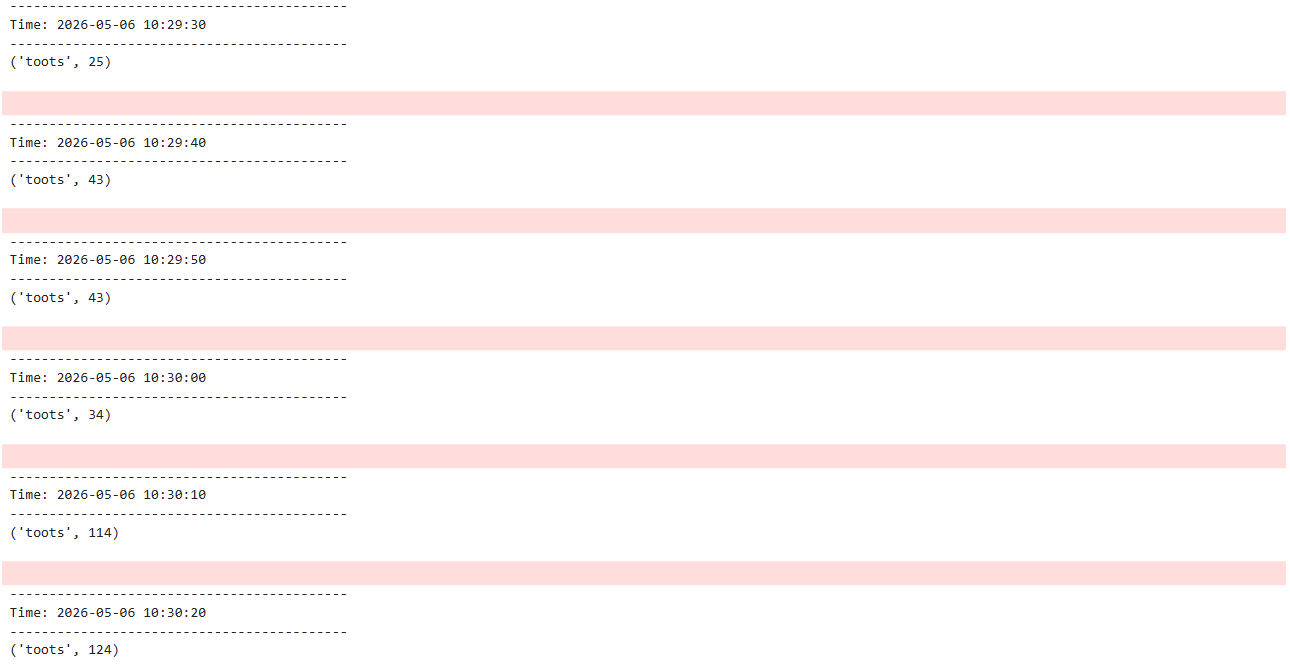

#### Exercici 10.2: Comptant Toots per Idioma (0.4 punts)

Com has observat a l'Exercici 2.1, el procés és bastant similar a treballar amb RDDs. 
Ara, aprofundirem en una anàlisi més complexa **comptant quants toots originals es creen 
per idioma cada 10 segons**. Per millorar la llegibilitat, et demanem que ordenïs 
els idiomes en ordre descendent segons el nombre de toots i limitïs la sortida als 5 principals idiomes.

**En aquest exercici, molt similar a l'anterior, el processament de les dades segueix diverses etapes:**

**- Cada línia de text es transforma en un objecte JSON amb json.loads.**

**- Es filtren els toots per eliminar els reblogs, mantenint només els toots originals.**

**- Cada toot es transforma en una parella (language, 1) per comptabilitzar els missatges per idioma.**

**- S’aplica una finestra temporal de 10 segons amb desplaçament de 10 segons mitjançant window(10, 10), per agrupar els resultats en intervals fixos.**

**Un cop agregades les dades, es calcula el nombre de toots per llengua amb reduceByKey, i després es fa un processament addicional amb transform per ordenar els resultats de major a menor freqüència,
assignar un índex amb zipWithIndex i seleccionar només els 5 idiomes més freqüents.**

In [ ]:
import findspark
findspark.init()

from pyspark import SparkContext
from pyspark.streaming import StreamingContext
import json

# Initialize SparkContext and StreamingContext with a 1-second batch interval
app_name = "Activity2_Ex10_1"  # Name of your application

# Create the SparkContext
try:
    sc = SparkContext("local[*]", appName = app_name)
except ValueError:
    sc.stop()
    sc = SparkContext("local[*]", appName = app_name)
sc.setLogLevel("ERROR")

# Create the StreamingContext
batch_interval = 5  # Batch interval in seconds
ssc = StreamingContext(sc, batch_interval)
ssc.checkpoint("checkpoint")  # Necessary for updateStateByKey operation

# Define stream parameters
socket_host = "localhost"  # or IP / localhost
socket_port = 9999

kafkaStream = ssc.socketTextStream(socket_host, socket_port)

# Converteim cada missatge (string JSON) en un diccionari Python
# Filtrem i eliminem els toots que són "reblogs" (retweets)
# Extraiem el camp "language" i assigna 1 per poder comptar-los. Si no hi ha idioma, posem "unknown"
# Apliquem una finestra temporal de 10 segons amb salt de 10 segons (agrupem les dades en intervals fixos)
# Sumem els valors per cada idioma dins de la finestra (comptem quants toots hi ha per llengua)
# Ordenem els resultats per nombre de toots (de més a menys)
# Assignem un índex a cada element (0, 1, 2, ...)
# Ens quedem només amb els 5 primers (top 5 llengües)
# Eliminem l’índex i ens quedem només amb (language, count)
tootLangCounts = kafkaStream \
    .map(lambda x: json.loads(x.strip())) \
    .filter(lambda toot: toot.get("reblog") is None) \
    .map(lambda toot: (toot.get("language", "unknown"), 1)) \
    .window(10, 10) \
    .reduceByKey(lambda a, b: a + b) \
    .transform(lambda rdd: rdd.sortBy(lambda x: x[1], ascending=False)
                        .zipWithIndex()
                        .filter(lambda x: x[1] < 5)
                        .map(lambda x: x[0]))

# Print the cumulative count
tootLangCounts.pprint(5)

# Start the computation
try:
    ssc.start()
    ssc.awaitTermination()
except KeyboardInterrupt:
    ssc.stop()
    sc.stop()

SLF4J: Class path contains multiple SLF4J bindings.
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/spark/jars/log4j-slf4j-impl-2.17.2.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/hadoop/lib/slf4j-reload4j-1.7.36.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/tez/lib/slf4j-reload4j-1.7.36.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: See http://www.slf4j.org/codes.html#multiple_bindings for an explanation.
SLF4J: Actual binding is of type [org.apache.logging.slf4j.Log4jLoggerFactory]


:: loading settings :: url = jar:file:/usr/bigtop/3.3.0/usr/lib/spark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/aestanymac/.ivy2/cache
The jars for the packages stored in: /home/aestanymac/.ivy2/jars
org.apache.spark#spark-sql-kafka-0-10_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-aaf00c3c-c70a-47cf-b216-798b83d1238e;1.0
	confs: [default]
	found org.apache.spark#spark-sql-kafka-0-10_2.12;3.3.0 in central
	found org.apache.spark#spark-token-provider-kafka-0-10_2.12;3.3.0 in central
	found org.apache.kafka#kafka-clients;2.8.1 in central
	found org.lz4#lz4-java;1.8.0 in central
	found org.xerial.snappy#snappy-java;1.1.8.4 in central
	found org.slf4j#slf4j-api;1.7.32 in central
	found org.apache.hadoop#hadoop-client-runtime;3.3.2 in central
	found org.spark-project.spark#unused;1.0.0 in central
	found org.apache.hadoop#hadoop-client-api;3.3.2 in central
	found commons-logging#commons-logging;1.1.3 in central
	found com.google.code.findbugs#jsr305;3.0.0 in central
	found org.apache.commons#commons-pool2;2.11.1 in central

-------------------------------------------
Time: 2026-05-06 10:34:20
-------------------------------------------
('en', 10)
(None, 8)
('nl', 3)
('de', 2)
('fr', 2)



-------------------------------------------
Time: 2026-05-06 10:34:30
-------------------------------------------
('en', 18)
('ja', 7)
(None, 6)
('es', 3)
('qme', 1)



-------------------------------------------
Time: 2026-05-06 10:34:40
-------------------------------------------
(None, 28)
('en', 24)
('ja', 6)
('de', 5)
('es', 3)



-------------------------------------------
Time: 2026-05-06 10:34:50
-------------------------------------------
(None, 20)
('ja', 14)
('en', 14)
('de', 8)
('sv', 4)



[Stage 0:>                                                          (0 + 1) / 1]

**Adjuntem la següent captura de pantalla amb els resultats:**

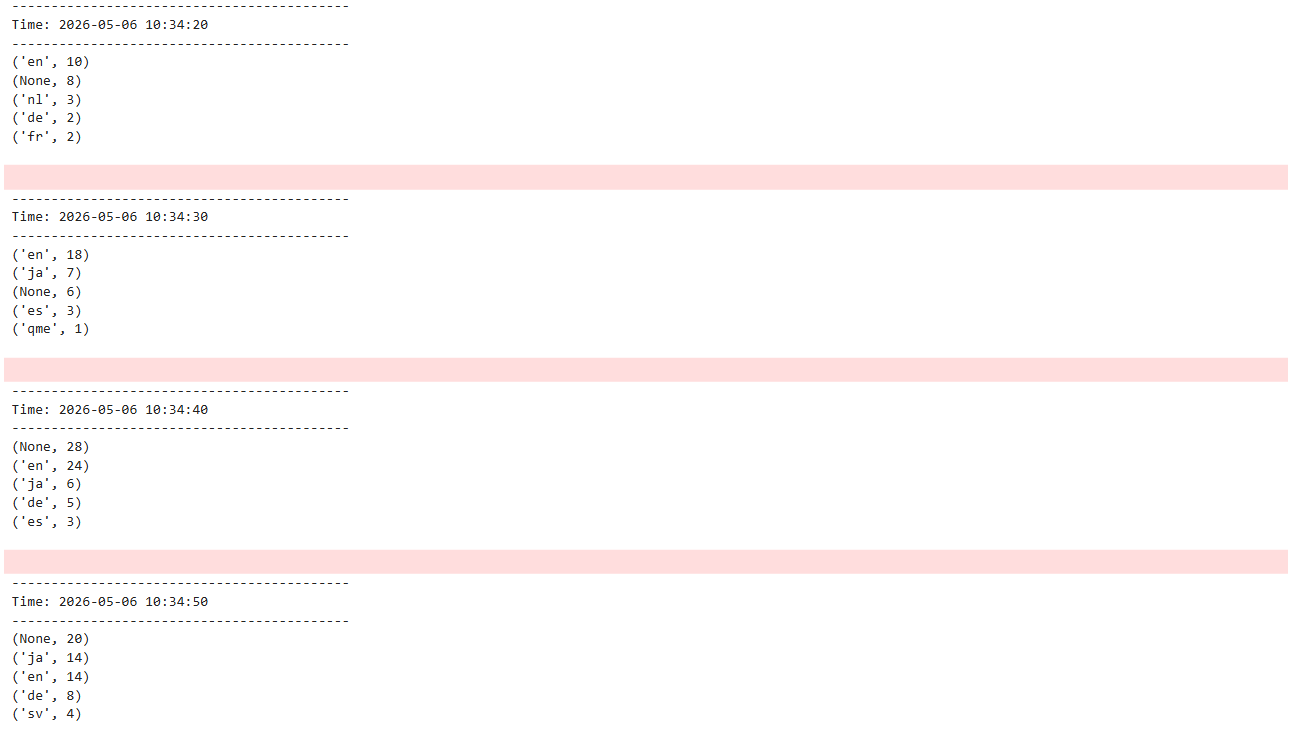

#### Exercici 10.3: Mantenint el Recompte (0.4 punts)


Fins ara, hem estat obtenint resultats específics de lots, cosa que generalment és útil. 
Però, què passa si vols obtenir una visió més àmplia, mantenint la informació a través de les 
finestres per, per exemple, acumular tendències al llarg del temps? 
Aquest és l'enfocament de la nostra propera exploració.

En aquest exercici, t'invitem a modificar l'script anterior per **mantenir un recompte acumulat de tots els toots originals, categoritzats per idioma**. En lloc de simplement comptar nous toots cada cinc segons, anem a **sumar-los contínuament**. Pensa-hi com un marcador que s'actualitza constantment amb el nombre total de toots originals en cada idioma des del moment en què vam començar a fer streaming.

Per aconseguir-ho, treballarem amb les transformacions 
[**stateful transformations in Spark Streaming**](https://downloads.apache.org/spark/docs/3.3.0/streaming-programming-guide.html#caching--persistence).
Aquesta és una forma sofisticada de dir que recordarem les dades passades i les utilitzarem 
en els nostres càlculs actuals. És similar a mantenir un total acumulat en una variable 
global en lloc de començar des de zero cada vegada.

**T'invitem a completar el següent script:**

**A diferència dels exercicis anteriors, on es calculava el nombre de toots dins d’una finestra temporal concreta, aquí es manté un recompte global acumulat des de l’inici de l’execució.**

**Com abans, cada missatge es converteix de text a objecte JSON amb json.loads, filtrem els toots que són reblogs, mantenint només els originals i cada toot es transforma en una parella (language, 1) per comptabilitzar per idioma.**

**A continuació, s’utilitza la funció updateStateByKey, que permet mantenir un estat persistent per cada clau (en aquest cas, cada idioma). Aquesta funció suma els nous valors rebuts en cada batch amb el valor acumulat anterior, construint així un recompte global continu. Finalment, es fa una ordenació dels resultats per nombre total de toots per idioma amb transform, mostrant primer els idiomes més utilitzats.**

In [ ]:
import findspark
findspark.init()

from pyspark import SparkContext
from pyspark.streaming import StreamingContext
import json

# Initialize SparkContext and StreamingContext with a 1-second batch interval
app_name = "Activity2_Ex10_3"  # Name of your application

# Create the SparkContext
try:
    sc = SparkContext("local[*]", appName="app_name")
except ValueError:
    sc.stop()
    sc = SparkContext("local[*]", appName="app_name")

sc.setLogLevel("ERROR")

batch_interval = 5  # Batch interval in seconds
ssc = StreamingContext(sc, batch_interval)
ssc.checkpoint("checkpoint")  # Necessary for updateStateByKey operation

# Define stream parameters
socket_host = "localhost"  # or IP / localhost
socket_port = 9999

kafkaStream = ssc.socketTextStream(socket_host, socket_port)

# Update the cumulative count using updateStateByKey
def updateFunction(newValues, runningCount):
    if runningCount is None:
        runningCount = 0
    return sum(newValues) + runningCount

# Count each toot as 1 and update the total count
tootCounts = kafkaStream \
    .map(lambda x: json.loads(x.strip())) \
    .filter(lambda toot: toot.get("reblog") is None) \
    .map(lambda toot: (toot.get("language", "unknown"), 1)) \
    .updateStateByKey(updateFunction) \
    .transform(lambda rdd: rdd.sortBy(lambda x: x[1], ascending=False))

# Print the cumulative count
tootCounts.pprint()

# Start the computation
try:
    ssc.start()
    ssc.awaitTermination()
except KeyboardInterrupt:
    ssc.stop()
    sc.stop()

SLF4J: Class path contains multiple SLF4J bindings.
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/spark/jars/log4j-slf4j-impl-2.17.2.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/hadoop/lib/slf4j-reload4j-1.7.36.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/tez/lib/slf4j-reload4j-1.7.36.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: See http://www.slf4j.org/codes.html#multiple_bindings for an explanation.
SLF4J: Actual binding is of type [org.apache.logging.slf4j.Log4jLoggerFactory]


:: loading settings :: url = jar:file:/usr/bigtop/3.3.0/usr/lib/spark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/aestanymac/.ivy2/cache
The jars for the packages stored in: /home/aestanymac/.ivy2/jars
org.apache.spark#spark-sql-kafka-0-10_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-3185cbc3-c637-4d85-92b3-23014f924164;1.0
	confs: [default]
	found org.apache.spark#spark-sql-kafka-0-10_2.12;3.3.0 in central
	found org.apache.spark#spark-token-provider-kafka-0-10_2.12;3.3.0 in central
	found org.apache.kafka#kafka-clients;2.8.1 in central
	found org.lz4#lz4-java;1.8.0 in central
	found org.xerial.snappy#snappy-java;1.1.8.4 in central
	found org.slf4j#slf4j-api;1.7.32 in central
	found org.apache.hadoop#hadoop-client-runtime;3.3.2 in central
	found org.spark-project.spark#unused;1.0.0 in central
	found org.apache.hadoop#hadoop-client-api;3.3.2 in central
	found commons-logging#commons-logging;1.1.3 in central
	found com.google.code.findbugs#jsr305;3.0.0 in central
	found org.apache.commons#commons-pool2;2.11.1 in central

-------------------------------------------
Time: 2026-05-06 10:40:15
-------------------------------------------
('en', 3)
(None, 1)
('ja', 1)
('de', 1)
('fr', 1)



-------------------------------------------
Time: 2026-05-06 10:40:20
-------------------------------------------
('en', 15)
(None, 9)
('fr', 8)
('ja', 2)
('de', 2)
('zh-CN', 1)



-------------------------------------------
Time: 2026-05-06 10:40:25
-------------------------------------------
('en', 31)
(None, 15)
('ja', 9)
('fr', 8)
('de', 4)
('es', 1)
('ar', 1)
('zh-CN', 1)
('vi', 1)
('it', 1)



-------------------------------------------
Time: 2026-05-06 10:40:30
-------------------------------------------
('en', 39)
(None, 21)
('fr', 12)
('ja', 11)
('de', 6)
('es', 2)
('ru', 1)
('ar', 1)
('zh-CN', 1)
('vi', 1)
...



-------------------------------------------
Time: 2026-05-06 10:40:35
-------------------------------------------
('en', 59)
(None, 31)
('ja', 12)
('fr', 12)
('de', 11)
('zh-CN', 3)
('es', 2)
('ru', 1)
('ar', 1)
('vi', 1)
...



-------------------------------------------
Time: 2026-05-06 10:40:40
-------------------------------------------
('en', 75)
(None, 39)
('ja', 14)
('de', 13)
('fr', 12)
('zh-CN', 3)
('es', 2)
('ru', 1)
('ar', 1)
('vi', 1)
...



-------------------------------------------
Time: 2026-05-06 10:40:45
-------------------------------------------
('en', 81)
(None, 47)
('ja', 18)
('de', 16)
('fr', 13)
('es', 4)
('zh-CN', 3)
('nl', 3)
('ko', 2)
('ru', 1)
...



[Stage 0:>                                                          (0 + 1) / 1]

**Captura de pantalla resultant:**

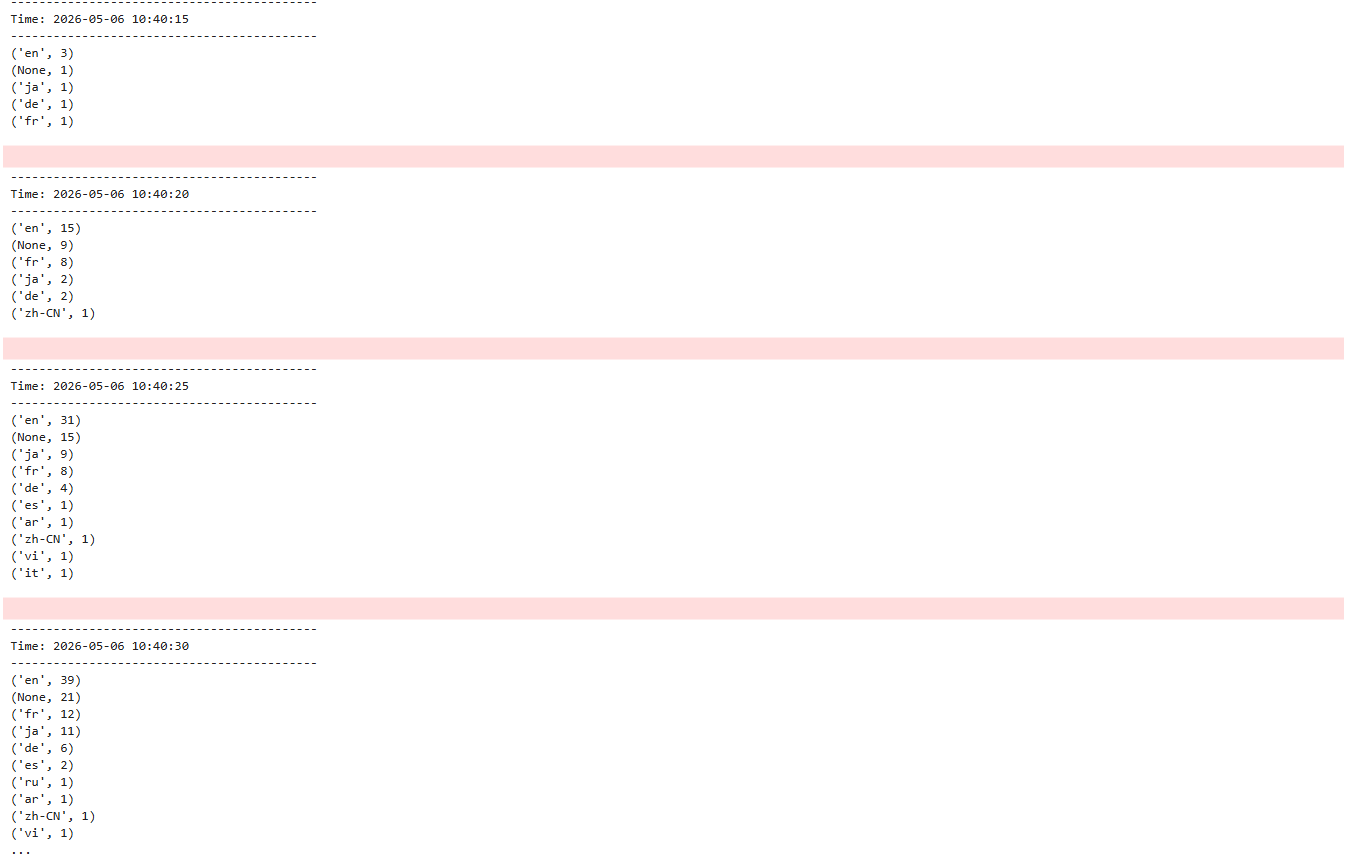

#### Exercici 10.4: Windowed Counting (0.5 punts)

Com has observat, Spark Streaming és increïblement flexible i 
fàcil d'usar, i aquí tens un truc interessant que pot realitzar: 
**et permet trobar un punt intermedi entre comptar toots en una [time
window](https://downloads.apache.org/spark/docs/3.3.0/streaming-programming-guide.html#window-operations)
i mantenir un total acumulat**. Imaginem que volem crear un panell de control, 
com un tauler, que mostri el nombre de toots realitzats en cada idioma. 
El gir és que **volem que aquesta actualització es produeixi cada 5 segons, 
però estem rastrejant els recomptes durant un minut complet**.

Així, cada 5 segons, el nostre panell s'actualitza, proporcionant-nos 
el darrer recompte acumulat durant un minut. És com tenir un marcador en viu 
que s'actualitza amb freqüència i també realitza un seguiment del que ha ocorregut 
en els darrers 60 segons, no només en els darrers 5. D'aquesta manera, obtens 
tant actualitzacions immediates com una vista més àmplia del que està ocorrent, 
tot al mateix temps. Mostra només els 10 principals idiomes.

**Modifica el següent script per aconseguir aquest objectiu:**


**En aquest exercici es processa un flux de dades en temps real provinent d’un socket, on cada missatge representa un toot en format JSON. En primer lloc, es parsegen les dades i es filtren els retweets (reblog) per assegurar que només es comptabilitzen toots originals. A continuació, cada toot es transforma en una parella clau-valor on la clau és l’idioma i el valor és 1, preparant així les dades per a l’agregació.**

**El recompte es realitza mitjançant una finestra de 60 segons amb un slide interval de 5 segons utilitzant reduceByKeyAndWindow [[16]](https://downloads.apache.org/spark/docs/3.3.0/streaming-programming-guide.html#window-operations), la qual permet calcular de manera contínua el nombre de toots per idioma dins dels darrers 60 segons. Aquest enfocament proporciona una visió en temps real però alhora contextualitzada, ja que no es limita només als últims 5 segons sinó que considera un historial recent més ampli.**

**Posteriorment, es fa un processament addicional per ordenar els idiomes segons el nombre de toots de manera descendent i es seleccionen només els 10 més actius en cada actualització (similar al que hem fet anteriorment).**

In [ ]:
import findspark
findspark.init()

from pyspark import SparkContext
from pyspark.streaming import StreamingContext
import json

# Initialize SparkContext and StreamingContext with a 5-second batch interval
app_name = "Exercici_10_4"  # Name of your application

# Create the SparkContext
try:
    sc = SparkContext("local[*]", appName=app_name)
except ValueError:
    sc.stop()
    sc = SparkContext("local[*]", appName=app_name)

sc.setLogLevel("ERROR")

ssc = StreamingContext(sc, 5)
ssc.checkpoint("checkpoint")  # Necessary for updateStateByKey operation

# Define stream parameters
socket_host = "localhost"  # or IP / localhost
socket_port = 9999

kafkaStream = ssc.socketTextStream(socket_host, socket_port)

# Count each toot as 1 and update the total count. Use a 60-second window with a 5-second slide
tootCounts = kafkaStream \
    .map(lambda x: json.loads(x.strip())) \
    .filter(lambda x: x.get("reblog") is None) \
    .map(lambda x: (x.get("language", "unknown"), 1)) \
    .reduceByKeyAndWindow(lambda a, b: a + b, 60, 5) \
    .transform(lambda rdd:
        rdd.sortBy(lambda x: -x[1])
           .zipWithIndex()
           .filter(lambda x: x[1] < 10)
           .map(lambda x: x[0])
    )

# Print the cumulative count
tootCounts.pprint()

# Start the computation
try:
    ssc.start()
    ssc.awaitTermination()
except KeyboardInterrupt:
    ssc.stop()
    sc.stop()

SLF4J: Class path contains multiple SLF4J bindings.
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/spark/jars/log4j-slf4j-impl-2.17.2.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/hadoop/lib/slf4j-reload4j-1.7.36.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/tez/lib/slf4j-reload4j-1.7.36.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: See http://www.slf4j.org/codes.html#multiple_bindings for an explanation.
SLF4J: Actual binding is of type [org.apache.logging.slf4j.Log4jLoggerFactory]


:: loading settings :: url = jar:file:/usr/bigtop/3.3.0/usr/lib/spark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/aestanymac/.ivy2/cache
The jars for the packages stored in: /home/aestanymac/.ivy2/jars
org.apache.spark#spark-sql-kafka-0-10_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-e739e674-0e82-45ef-86e6-277329955f89;1.0
	confs: [default]
	found org.apache.spark#spark-sql-kafka-0-10_2.12;3.3.0 in central
	found org.apache.spark#spark-token-provider-kafka-0-10_2.12;3.3.0 in central
	found org.apache.kafka#kafka-clients;2.8.1 in central
	found org.lz4#lz4-java;1.8.0 in central
	found org.xerial.snappy#snappy-java;1.1.8.4 in central
	found org.slf4j#slf4j-api;1.7.32 in central
	found org.apache.hadoop#hadoop-client-runtime;3.3.2 in central
	found org.spark-project.spark#unused;1.0.0 in central
	found org.apache.hadoop#hadoop-client-api;3.3.2 in central
	found commons-logging#commons-logging;1.1.3 in central
	found com.google.code.findbugs#jsr305;3.0.0 in central
	found org.apache.commons#commons-pool2;2.11.1 in central

**El resultat obtingut és:**

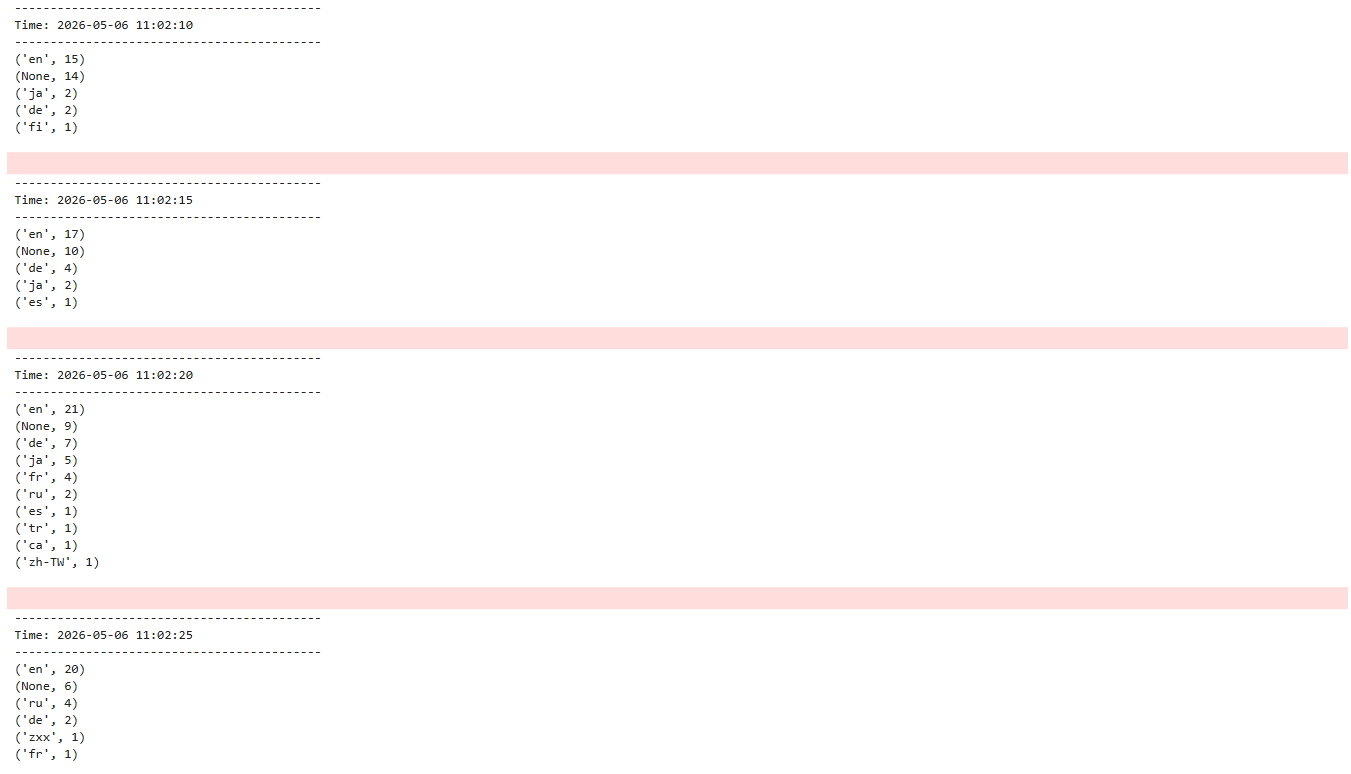

### Exercici 10.5: Powering Up (1 punt)


Molt bé, ja sabem que els RDDs en Spark són increïblement versàtils: 
són com la navalla suïssa del processament de dades d'stream. Pots fer pràcticament 
qualsevol operació amb ells. Tanmateix, **a mesura que les coses es tornen més complexes, 
el repte augmenta.**

Ara, anem a fer el nostre panell de control encara més interessant. En lloc de només mostrar 
quants toots tenim per minut, afegim algunes característiques noves. 
No seria interessant **rastrejar la longitud mitjana d'aquests toots?**
I hi ha més: anem a descobrir **qui és l'usuari amb més seguidors entre els que han tootejat en aquell minut.**

Espera, **¡hi ha més!** Per fer tota aquesta informació súper fàcil de llegir i entendre, la presentarem en un format de taula ordenat i net. No es tracta només de les dades, sinó de fer-les amigables per a l'usuari i visualment digeribles.

La taula resultant s'ha d'actualitzar en intervals de 5 segons, i les finestres de mitjana han de ser de 60 segons. Les columnes d'aquesta taula han de ser:
    
-   **`lang`:** Idioma
-   **`num_toots`:** Nombre de toots originals en aquell idioma
-   **`avg_len_content`:** Longitud mitjana (en caràcters) del contingut del toot
-   **`user`:** Usuari amb més seguidors
-   **`followers`:** Nombre de seguidors d'aquest usuari

Per fer la sortida més llegible, limita el nombre de files a 10.

**TIP:** Hi ha un exemple molt útil a [Spark Streaming](https://downloads.apache.org/spark/docs/3.3.0/streaming-programming-guide.html#dataframe-and-sql-operations). Busca'l!


**En aquest cas, s’estableixen tres càlculs paral·lels basats en finestres de 60 segons amb actualització cada 5 segons. Per una banda, el nombre de toots per idioma (lang_counts), no escompten els toots agrupats per llengua utilitzant una finestra temporal mòbil; després la longitud mitjana del contingut (lang_avg), on calculem la suma acumulada de caràcters i el nombre de toots per idioma per obtenir la mitjana (on utilitzem les funcions d’“afegir i restar” per mantenir correctament la finestra lliscant). I finalment l'usuari amb més seguidors (top_user) per cada idioma i el nombre màxim de seguidors d'aquest.**

**Després els 3 fluxos els unim amb un join per idioma (key), obtenint l'estructura que se'ns demana.** 

**Finalment, es defineix una funció foreachRDD [[17]](https://sandeepkattepogu.medium.com/streaming-data-from-apache-kafka-topic-using-apache-spark-2-4-5-and-python-4073e716bdca) [[18]](https://spark.apache.org/docs/latest/streaming-programming-guide?) que imprimeix els resultats de cada batch en format de taula, limitant la sortida a 10 files per facilitar la lectura.**

In [ ]:
import findspark
findspark.init()

from pyspark import SparkContext
from pyspark.streaming import StreamingContext
import json


app_name = "Exercici_10_5"

sc = SparkContext("local[*]", appName=app_name)
sc.setLogLevel("ERROR")

ssc = StreamingContext(sc, 5)
ssc.checkpoint("checkpoint")

stream = ssc.socketTextStream("localhost", 9999)

# parsejem els toots convertint les JSON strings a diccionari de Python
# i filtrem per quedar-nos només amb els originals
parsed = stream \
    .map(lambda x: json.loads(x)) \
    .filter(lambda x: x.get("reblog") is None)

# agafem l'idioma de cada toot, i ho convertim a una parella (lang, 1)
# i despres sumem les parelles del mateix idioma per tenir el recompte
# ho fem mirant els ultims 60 segons i actualitzant cada 5 segons (com la finestra de l'exercici anterior)
lang_counts = parsed \
    .map(lambda x: (x.get("language", "unknown"), 1)) \
    .reduceByKeyAndWindow(lambda a, b : a + b, 60, 5)

# convertim cada toot i ho convertim en (idioma, (longitud_text, 1))
# agrupem per idioma i aleshores tenim tuples (suma_textos_mateix_idioma, nombre_toots)
# tambe hem de fer la resta, per restar de l'agregació els toots que deixen de ser de la finestra perquè son massa vells (sino computariem des de 0, no per finestra lliscant)
lang_sum = parsed \
    .map(lambda x: (
        x.get("language", "unknown"), (len(x.get("content", "")), 1)
    )) \
    .reduceByKeyAndWindow(
        lambda a, b: (a[0] + b[0], a[1] + b[1]), # per sumar les dades noves que entren a la finestra
        lambda a, b: (a[0] - b[0], a[1] - b[1]), # per treure dades velles que surten de la finestra perque la finestra es mou
        60, # mirem ultims 60 segons
        5 # i recalculem cada 5 segons
    )

# volem extreure la mitjana de la llargada dels toots, per tant: llargada dels toots/nombre de toots
lang_avg = lang_sum.mapValues(lambda x: x[0] / x[1] if x[1] != 0 else 0)

# per extreure l'idioma, usuari i nombre de seguidors en format (idioma, (usuari, seguidors))
# i despres reduir segons la key (idioma). Aleshores ens quedem amb l'usuari amb mes seguidors
top_user = parsed \
    .map(lambda x: (
        x.get("language", "unknown"),
        (
            x.get("account", {}).get("username", "-"),
            x.get("account", {}).get("followers_count", 0)
        )
    )) \
    .reduceByKeyAndWindow(lambda a, b: a if a[1] >= b[1] else b, 60, 5)  # escollim l'usuari amb el maxim de seguidors

# unim les 3 tuples:
# lang_counts te el format (idioma, nombre de toots) 
# lang_avg te el format (idioma, llargada mitjana)
# top_user te el format (idioma, (top usuari, seguidors))
# al final tenim (idioma, ((num_toots, llargada mitjana)), ((top usuari, seguidors)))
joined = lang_counts \
    .join(lang_avg) \
    .join(top_user)

# nomes per fer el print en consola
def show(rdd):  # s'executara per cada batch
    rows = rdd.take(10) # limitem a 10

    print("\n" + "-" * 90)
    print(f"{'LANG':10} | {'TOOTS':6} | {'AVG_LEN':10} | {'USER':20} | {'FOLLOWS'}") # alineem columnes
    print("-" * 90)

    for r in rows: # comprovem el format i contingut de les columnes per evitar errors de format (string, number, float, etc)
        lang = r[0] if r[0] is not None else "unknown"
        toots = r[1][0][0] if r[1][0][0] is not None else 0
        avg_len = float(r[1][0][1] if r[1][0][1] is not None else 0.0)
        user = r[1][1][0] if r[1][1][0] is not None else "-"
        followers = r[1][1][1] if r[1][1][1] is not None else 0

        print(f"{lang:10} | {toots:6} | {avg_len:10.1f} | {user:20} | {followers}")

    print("-" * 90 + "\n")
    
joined.foreachRDD(show)  # fem el print de cada batch de les dades capturades [17-18]

ssc.start()
ssc.awaitTermination()

SLF4J: Class path contains multiple SLF4J bindings.
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/spark/jars/log4j-slf4j-impl-2.17.2.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/hadoop/lib/slf4j-reload4j-1.7.36.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/tez/lib/slf4j-reload4j-1.7.36.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: See http://www.slf4j.org/codes.html#multiple_bindings for an explanation.
SLF4J: Actual binding is of type [org.apache.logging.slf4j.Log4jLoggerFactory]


:: loading settings :: url = jar:file:/usr/bigtop/3.3.0/usr/lib/spark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/aestanymac/.ivy2/cache
The jars for the packages stored in: /home/aestanymac/.ivy2/jars
org.apache.spark#spark-sql-kafka-0-10_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-c556d8e9-c462-4e76-9918-fa7e1795b978;1.0
	confs: [default]
	found org.apache.spark#spark-sql-kafka-0-10_2.12;3.3.0 in central
	found org.apache.spark#spark-token-provider-kafka-0-10_2.12;3.3.0 in central
	found org.apache.kafka#kafka-clients;2.8.1 in central
	found org.lz4#lz4-java;1.8.0 in central
	found org.xerial.snappy#snappy-java;1.1.8.4 in central
	found org.slf4j#slf4j-api;1.7.32 in central
	found org.apache.hadoop#hadoop-client-runtime;3.3.2 in central
	found org.spark-project.spark#unused;1.0.0 in central
	found org.apache.hadoop#hadoop-client-api;3.3.2 in central
	found commons-logging#commons-logging;1.1.3 in central
	found com.google.code.findbugs#jsr305;3.0.0 in central
	found org.apache.commons#commons-pool2;2.11.1 in central


------------------------------------------------------------------------------------------
LANG       | TOOTS  | AVG_LEN    | USER                 | FOLLOWS
------------------------------------------------------------------------------------------
unknown    |      3 |      180.7 | nys_7                | 344
en         |     11 |      401.6 | AriWasserman         | 64400
------------------------------------------------------------------------------------------




------------------------------------------------------------------------------------------
LANG       | TOOTS  | AVG_LEN    | USER                 | FOLLOWS
------------------------------------------------------------------------------------------
unknown    |      1 |      193.8 | hamakaiji9064m       | 1506
bg         |      1 |     1058.0 | gabrielazaneva       | 18
en         |     21 |      511.7 | MLB                  | 13120000
de         |      3 |      996.0 | Weinberg             | 741
tr         |      1 |       82.0 | halktvcomtr          | 1758
nl         |      1 |      321.0 | atog                 | 380
fr         |      2 |      907.5 | mamie_ecrit          | 52
lv         |      1 |     1406.0 | lv                   | 10
------------------------------------------------------------------------------------------




------------------------------------------------------------------------------------------
LANG       | TOOTS  | AVG_LEN    | USER                 | FOLLOWS
------------------------------------------------------------------------------------------
unknown    |      4 |      416.4 | Chromograaf1         | 73
es         |      1 |      920.0 | pristy_CRG           | 116
zxx        |      2 |        7.0 | NHLBlackhawks        | 2160000
en         |     18 |      521.3 | NHLBlackhawks        | 2160000
de         |      1 |      768.5 | vio                  | 342
pt         |      2 |      179.0 | duran                | 582
fr         |      1 |     1370.0 | fr                   | 254
------------------------------------------------------------------------------------------




------------------------------------------------------------------------------------------
LANG       | TOOTS  | AVG_LEN    | USER                 | FOLLOWS
------------------------------------------------------------------------------------------
unknown    |      6 |      321.5 | hamakaiji9064m       | 1506
es         |      1 |      976.5 | es                   | 32
en         |     10 |      503.2 | SportsNetLA          | 175000
de         |      1 |      654.2 | cmister26            | 56
nl         |      2 |      256.3 | CyclesSmiles         | 556
it         |      1 |      622.0 | csseo                | 94
------------------------------------------------------------------------------------------




------------------------------------------------------------------------------------------
LANG       | TOOTS  | AVG_LEN    | USER                 | FOLLOWS
------------------------------------------------------------------------------------------
unknown    |      9 |      337.0 | 5101Tmd              | 427
en         |     16 |      525.8 | sargoth              | 1979
de         |      1 |      630.7 | BytesDE              | 107
tr         |      1 |      397.5 | kagane               | 8
zh-CN      |      1 |       20.0 | insuaal              | 183
nl         |      1 |      196.0 | roosvonk.bsky.social | 110
------------------------------------------------------------------------------------------



[Stage 0:>                                                          (0 + 1) / 1]

**Els resultats obtinguts són:**

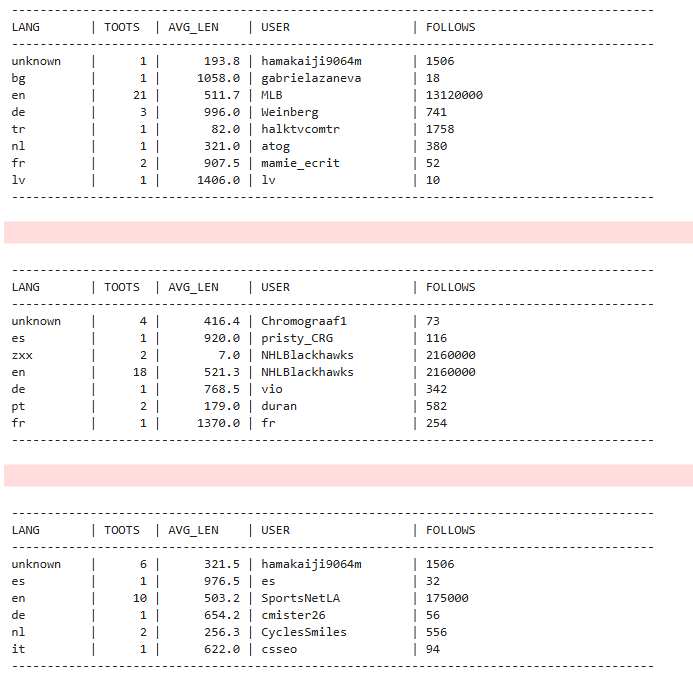

## Exercici 11: Structured Streaming (2.6 punts)

Com has vist en l'últim exercici, depenent de les operacions, 
l'API de Spark Streaming pot no resultar tan convenient, 
especialment perquè has de tractar amb APIs de baix nivell. Afortunadament, **Spark provides a
high-level API called [Spark Structured
Streaming](https://downloads.apache.org/spark/docs/3.3.0/structured-streaming-programming-guide.html)** que et permet **expressar els càlculs d'streaming de la mateixa manera que expressaries un càlcul per lots sobre dades estructurades estàtiques**, com les que usaries en el processament per lots.

En aquest conjunt d'exercicis, et submergirás en el fascinant món de Spark Structured Streaming.

## Exercici 11.1: Getting the Schema (0.3 punts)

Una de les característiques més interessants de Spark Structured Streaming és 
**com gestiona les dades estructurades**. Per exemple, el flux de dades en el nostre tema de Kafka, 
on **cada "toot" arriba en un format JSON ordenat**, cosa que el fa estructurat i organitzat.

De manera similar a com es treballa amb DataFrames a Spark, **Structured Streaming usa esquemes de dades per analitzar dades estructurades**, essencialment un plànol de com estan disposades les dades. Per al processament per lots, Spark pot sovint deduir aquesta estructura directament de les dades. Tanmateix, amb les dades d'streaming, és una mica diferent: **hem de definir aquesta estructura prèviament.**

En els exercicis següents, utilitzarem un truc convenient: **en lloc de definir manualment**
l'estructura complexa d'un "toot", inicialment **extraurem alguns toots de Kafka i els analitzarem en un lot per aprendre el seu esquema**. És com fer un cop d'ull per entendre com estan organitzades les coses. 
Un cop tinguem l'esquema, l'aplicarem a la nostra pipeline d'streaming.

La teva tasca en aquest exercici és realitzar aquesta transformació. Després, utilitzant les operacions de DataFrame amb les quals ja estàs familiaritzat, crearàs una taula amb les columnes següents que ens permetrà veure els toots individualment a mesura que es processen:


-   **`id`:** Identificador únic per a cada toot
-   **`created_at`:** Data i hora en què es va crear el toot
-   **`content`:** El contingut del toot
-   **`language`:** L'idioma del toot
-   **`username`:** El nom d'usuari de l'autor del toot
-   **`followers_count`:** Nombre de seguidors de l'autor.


Recorda que ens **interessen els toots originals**. Filtra els que són retweets.

Un altre aspecte fonamental que has de gestionar aquí és **seleccionar el outputMode adequat**. Consulta 
[la documentació](https://downloads.apache.org/spark/docs/3.3.0/structured-streaming-programming-guide.html#output-modes)
i tria el que millor s'adapti a aquest exercici.


**L’objectiu principal és obtenir i aplicar l’esquema de les dades per poder treballar de manera estructurada en els següents exercicis.**

**Com que en streaming les dades no permeten inferir l’esquema de forma automàtica, s’ha utilitzat una estratègia híbrida: primer s’ha llegit un petit conjunt de dades en mode batch des de Kafka per analitzar-ne l’estructura i inferir-ne l’esquema. Aquest esquema s’utilitza posteriorment per interpretar correctament els missatges que arriben en temps real.**

**Un cop obtingut l’esquema, es crea el flux de dades en streaming des del mateix topic de Kafka. A continuació, es transformen els missatges JSON en un DataFrame estructurat i es filtren únicament els toots originals, excloent els retweets (reblog).**

**Finalment, es construeix una taula amb els camps més rellevants per a l’anàlisi: identificador del toot, data de creació, contingut, idioma, nom d’usuari i nombre de seguidors de l’autor. Aquesta selecció permet visualitzar de manera clara cada missatge individual a mesura que es processa.**

**Pel que fa a la sortida del stream, s’ha triat el mode append, ja que en aquest exercici es mostren registres individuals a mesura que arriben, sense necessitat de recalcular resultats agregats [[19]](https://downloads.apache.org/spark/docs/3.3.0/structured-streaming-programming-guide.html#output-modes)**

In [ ]:
import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql.types import StringType, StructType, StructField
from pyspark import SparkConf, SparkContext
from pyspark.sql.functions import json_tuple, from_json, col
from pyspark.sql import SparkSession

conf = SparkConf()
conf.setMaster("local[*]")
sc = SparkContext(conf=conf)
sc.setLogLevel("ERROR")

# Initialize Spark Session for Structured Streaming
app_name = "activity11_1_aestanymac&nlopezlopez" # Replace with your Spark app name must include the username of the members of the group

spark = SparkSession \
    .builder \
    .appName(app_name) \
    .getOrCreate()

# Define Kafka parameters
kafka_topic = "mastodon_toots"
kafka_bootstrap_servers = "eimtcld3node1:9092"  # Replace with your Kafka bootstrap servers

# Read a small batch of data from Kafka for schema inference!
batch_df = spark \
    .read \
    .format("kafka") \
    .option("kafka.bootstrap.servers", kafka_bootstrap_servers) \
    .option("subscribe", kafka_topic) \
    .option("startingOffsets", "earliest") \
    .load()

# Infer schema
schema = spark.read.json(batch_df.selectExpr("CAST(value AS STRING)").rdd.map(lambda x: x[0])).schema

# Create streaming DataFrame by reading data from Kafka
toots = spark \
    .readStream \
    .format("kafka") \
    .option("kafka.bootstrap.servers", kafka_bootstrap_servers) \
    .option("subscribe", kafka_topic) \
    .option("startingOffsets", "earliest") \
    .option("maxOffsetsPerTrigger", 50) \
    .load()

# Parse the value column as JSON and apply the infered schema. Then select the columns we need.
toots_df = toots \
    .select(from_json(col("value").cast("string"), schema).alias("parsed_value")) \
    .filter(col("parsed_value.reblog").isNull()) \
    .select(
        col("parsed_value.id").alias("id"),
        col("parsed_value.created_at").alias("created_at"),
        col("parsed_value.content").alias("content"),
        col("parsed_value.language").alias("language"),
        col("parsed_value.account.username").alias("username"),
        col("parsed_value.account.followers_count").alias("followers_count")
    ) 

try:
    # Open stream to console (you need to execute it in a terminal to see the output)
    query = toots_df \
        .writeStream \
        .outputMode("append") \
        .format("console") \
        .option("truncate", "true") \
        .option("numRows", 5) \
        .start()

    query.awaitTermination()

except KeyboardInterrupt:
    query.stop()
    spark.stop()
    sc.stop()

SLF4J: Class path contains multiple SLF4J bindings.
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/spark/jars/log4j-slf4j-impl-2.17.2.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/hadoop/lib/slf4j-reload4j-1.7.36.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/tez/lib/slf4j-reload4j-1.7.36.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: See http://www.slf4j.org/codes.html#multiple_bindings for an explanation.
SLF4J: Actual binding is of type [org.apache.logging.slf4j.Log4jLoggerFactory]


:: loading settings :: url = jar:file:/usr/bigtop/3.3.0/usr/lib/spark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/aestanymac/.ivy2/cache
The jars for the packages stored in: /home/aestanymac/.ivy2/jars
org.apache.spark#spark-sql-kafka-0-10_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-b978c033-265c-436a-bd1f-815ced27b8f5;1.0
	confs: [default]
	found org.apache.spark#spark-sql-kafka-0-10_2.12;3.3.0 in central
	found org.apache.spark#spark-token-provider-kafka-0-10_2.12;3.3.0 in central
	found org.apache.kafka#kafka-clients;2.8.1 in central
	found org.lz4#lz4-java;1.8.0 in central
	found org.xerial.snappy#snappy-java;1.1.8.4 in central
	found org.slf4j#slf4j-api;1.7.32 in central
	found org.apache.hadoop#hadoop-client-runtime;3.3.2 in central
	found org.spark-project.spark#unused;1.0.0 in central
	found org.apache.hadoop#hadoop-client-api;3.3.2 in central
	found commons-logging#commons-logging;1.1.3 in central
	found com.google.code.findbugs#jsr305;3.0.0 in central
	found org.apache.commons#commons-pool2;2.11.1 in central

**El codi anterior s'ha executat mitjançant un fitxer Python creat (File -> New -> Python File) que conterina el codi, i executant a la terminal de Jupyter Lab la següent comanda:**



**I al cap d'una estona hem començat a rebre els toots:**

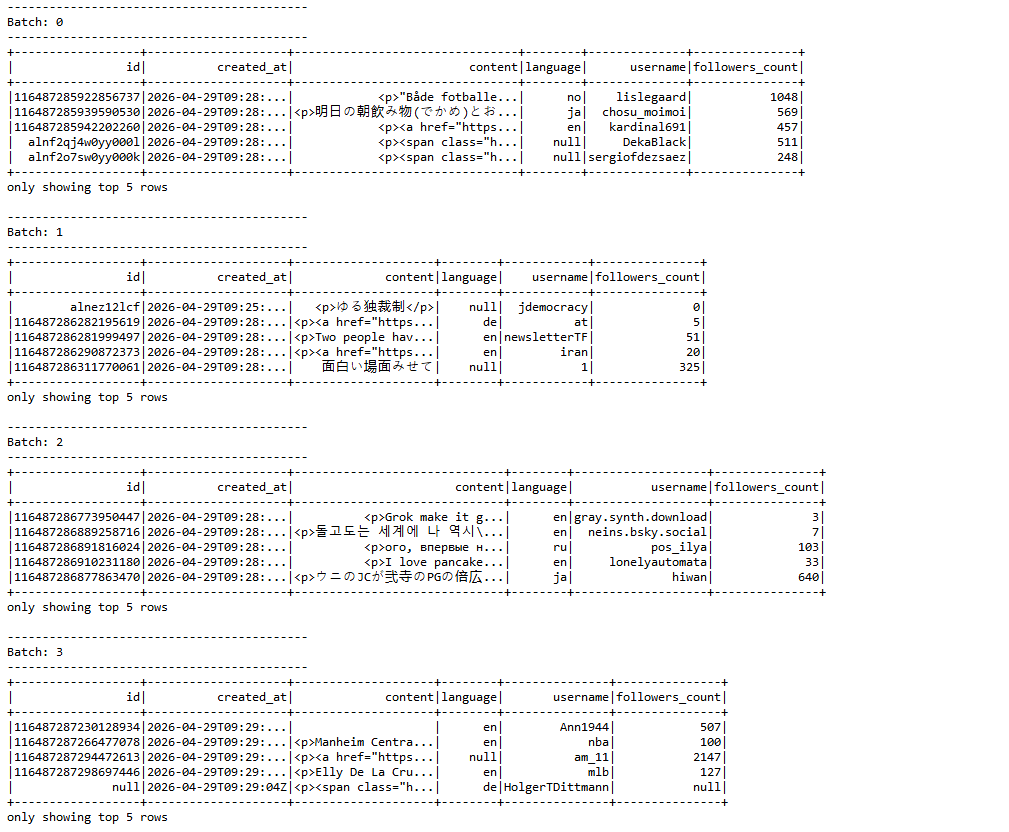
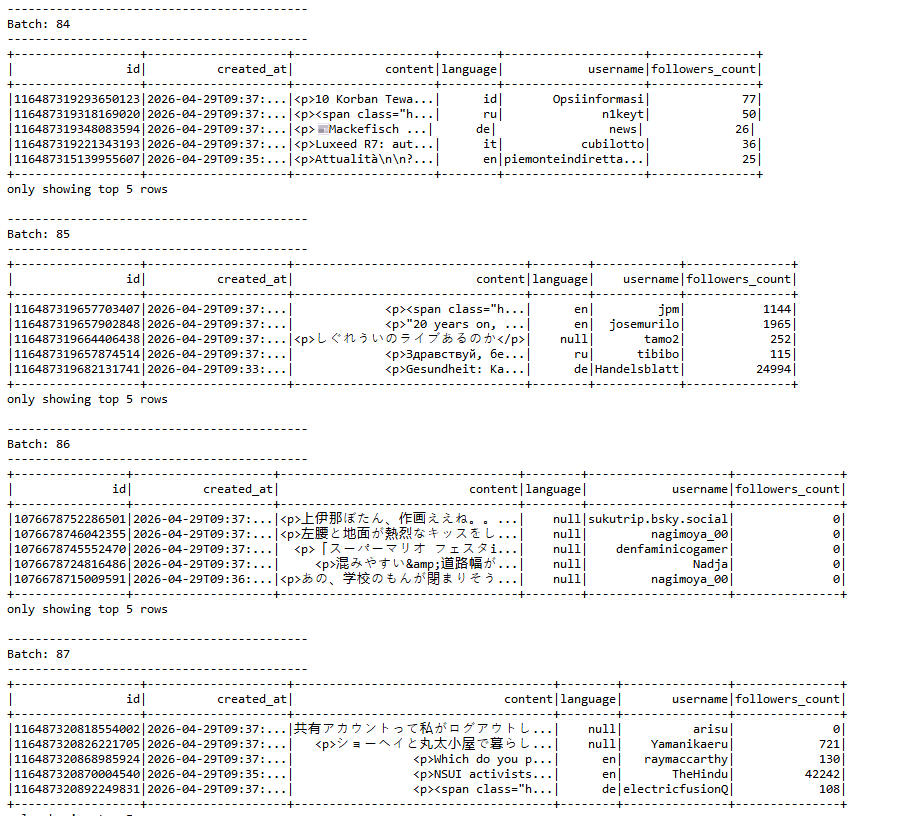


### Exercici 11.2: Agregant Dades des d'un Flux (0.3 punts)

Spark Structured Streaming és realment poderós, especialment quan es realitzen operacions sobre un flux continu de dades. En aquest exercici, aprofundirem en Structured Spark Streaming, centrant-nos específicament en l'agregació de dades des d'un flux de Kafka. És similar al que vam fer a l'Exercici 2. La teva missió és **comptar el nombre de toots originals en cada idioma.**

Aquí et mostrem com ha de ser la teva sortida:

-   **`language`:** Aquesta columna mostra l'idioma dels toots.
-   **`count`:** Aquí és on mostraràs el nombre de toots per cada idioma.

La teva taula ha d'**acumular aquests recomptes cada 10 segons, i també ha de continuar acumulant-los**. A més, fes-la amigable per a l'usuari **ordenant els idiomes pel nombre de toots, amb els idiomes més parladors a la part superior.**

Ara, aquí hi ha una **part clau** d'aquest exercici: **has de triar el mode de sortida adequat per a la teva consulta d'streaming**. Recorda, el **mode de sortida determina com s'escriu cada lot de dades resultant al destí de sortida**. Les teves opcions són els modes 'Complete', 'Append' i 'Update'. Pensa quin encaixa millor per al nostre escenari de recompte acumulatiu i ordenat. I **no oblidis escriure el teu raonament als comentaris.**


**L’objectiu és calcular el nombre de toots originals per idioma i mantenir aquests recomptes actualitzats en temps real.**

**Partint del mateix esquema de dades definit a l’exercici anterior, es torna a crear el flux de streaming i es processen els missatges JSON per extreure únicament els camps necessaris. A continuació, es filtra de nou per eliminar els retweets (reblog) i els registres sense idioma definit, assegurant que només es treballa amb toots originals vàlids.**

**Un cop netes les dades, es realitza una agregació utilitzant groupBy(language) i count(), amb l’objectiu de comptabilitzar quants toots s’han generat per cada idioma. Per millorar la llegibilitat dels resultats, s'ordenen descendentment segons el nombre de toots.**

**Un aspecte clau d’aquest exercici és la selecció del mode de sortida del stream. S’ha escollit el mode complete, ja que en aquest cas es treballa amb una agregació contínua i es necessita mostrar en cada actualització el resultat global acumulat de tots els idiomes fins al moment. El mode append no és adequat perquè no permet mostrar resultats intermedis d’agregacions, i el mode update només mostraria les files modificades en cada batch, dificultant la interpretació del rànquing global.**

**Finalment, el stream s’actualitza cada 10 segons mitjançant un trigger temporal, permetent observar l’evolució progressiva dels idiomes més utilitzats a la plataforma.**

In [ ]:
import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql.types import StringType, StructType, StructField
from pyspark import SparkConf, SparkContext
from pyspark.sql.functions import from_json, col, window
from pyspark.sql import SparkSession

conf = SparkConf()
conf.setMaster("local[*]")
sc = SparkContext(conf=conf)
sc.setLogLevel("ERROR")

# Initialize Spark Session for Structured Streaming
app_name = "activity3_2_aestanymac&nlopezlopez" # Replace with your Spark app name must include the username of the members of the group

spark = SparkSession \
    .builder \
    .appName(app_name) \
    .getOrCreate()

# Define Kafka parameters
kafka_topic = "mastodon_toots"
kafka_bootstrap_servers = "eimtcld3node1:9092"  # Replace with your Kafka bootstrap servers

# Read a small batch of data from Kafka for schema inference!
batch_df = spark \
    .read \
    .format("kafka") \
    .option("kafka.bootstrap.servers", kafka_bootstrap_servers) \
    .option("subscribe", kafka_topic) \
    .option("startingOffsets", "earliest") \
    .load()

# Infer schema
schema = spark.read.json(batch_df.selectExpr("CAST(value AS STRING)").rdd.map(lambda x: x[0])).schema

# Create streaming DataFrame by reading data from Kafka
toots = spark \
    .readStream \
    .format("kafka") \
    .option("kafka.bootstrap.servers", kafka_bootstrap_servers) \
    .option("subscribe", kafka_topic) \
    .option("startingOffsets", "latest") \
    .load()

# Parse the value column as JSON and apply the infered schema. Then select the columns we need.
toots_df = toots \
    .select(from_json(col("value").cast("string"), schema).alias("parsed_value")) \
    .select(
        col("parsed_value.language").alias("language"),
        col("parsed_value.created_at").alias("created_at"),
        col("parsed_value.reblog").alias("reblog")
    ) \
    .filter((col("reblog").isNull()) & (col("language").isNotNull())) \
    .groupBy("language") \
    .count() \
    .orderBy(col("count").desc())

try:
    # Open stream to console (you need to execute it in a terminal to see the output)
    query = toots_df \
        .writeStream \
        .outputMode("complete") \
        .format("console") \
        .option("truncate", "true") \
        .trigger(processingTime="10 seconds") \
        .start()

    query.awaitTermination()
except KeyboardInterrupt:
    query.stop()
    spark.stop()
    sc.stop()

**De forma similar a l'exercici 11.1, hem guardat el codi en un fitxer py i l'hem executat des de la terminal de Jupyter Lab com:**



**Els resultats son:**

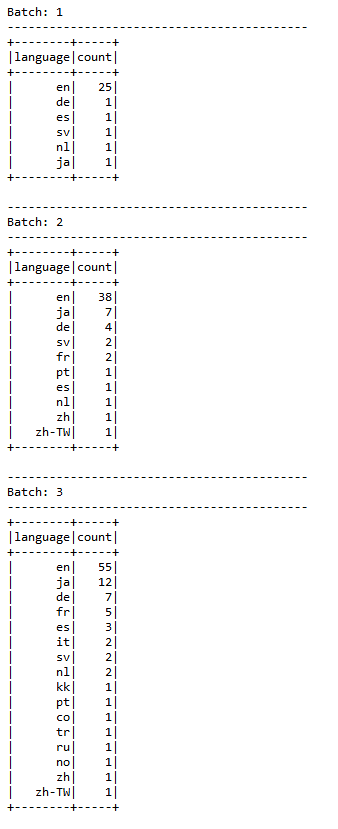

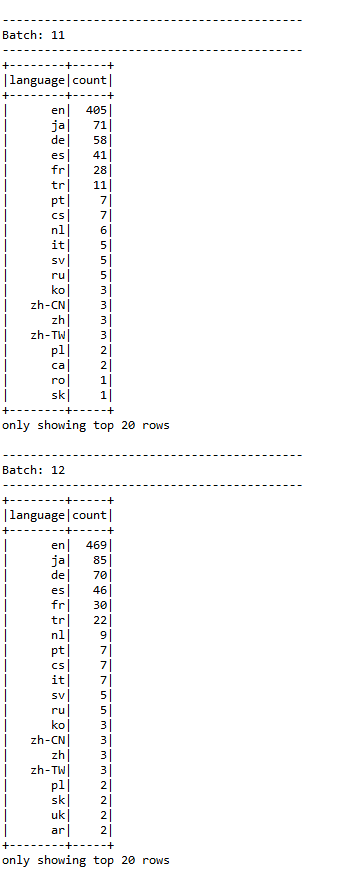

### Exercici 11.3: Windowed Counting (1 punt)

Bon treball! Has après a realitzar agregacions i a fer un seguiment dels recomptes al llarg del temps. Com vas notar a l'Exercici 2.4, de vegades és més efectiu mantenir aquests recomptes en **finestres de temps específiques**. Ara, volem que apliquis aquesta tècnica utilitzant [functions available in Spark Structured
Streaming](https://downloads.apache.org/spark/docs/3.3.0/structured-streaming-programming-guide.html#window-operations-on-event-time). 
Tingues en compte que Spark Structured Streaming gestiona el temps de manera diferent a Spark Streaming, per la qual cosa hauràs de considerar-ho en analitzar i interpretar els resultats.

La teva tasca és **crear una taula que mostri un recompte de la quantitat de toots originals (recorda filtrar els retweets) realitzats en cada idioma, segmentats dins d'un marc de temps específic.** Per a aquest exercici, has d'usar una sliding window d'un minut, amb les dades refrescant-se cada 5 segons. Aquest enfocament et permetrà monitorar de prop la freqüència dels toots en diferents idiomes al llarg d'intervals breus i superposats.

Et demanem que proporcionis una taula amb l'estructura següent:

- **`window`:** Mostra el rang de temps
- **`language`:** Aquesta columna mostra l'idioma dels toots.
- **`count`:** Aquí és on mostraràs el nombre de toots per a cada idioma.

Els resultats s'han d'**ordenar per finestra de temps i recompte en ordre descendent.**


**Ara es vol obtenir el nombre de toots originals per idioma dins de finestres mòbils d’1 minut, amb actualitzacions cada 5 segons [[20]](https://downloads.apache.org/spark/docs/3.3.0/structured-streaming-programming-guide.html#window-operations-on-event-time) [[21]](https://medium.com/@kiranvutukuri/output-modes-in-apache-spark-structured-streaming-part-3-9f4086c8667b). Aquest enfocament de sliding window permet observar com varia l’activitat dels diferents idiomes de manera contínua i amb solapament entre intervals, proporcionant una visió més fina i dinàmica del comportament del flux.**

**Per fer-ho, es parteix del flux de dades ja estructurat i filtrat en exercicis anteriors, mantenint només els toots originals i amb idioma definit. A continuació, s’aplica una agregació combinant la finestra temporal (window) i l’idioma com a dimensions de grup, i es calcula el recompte de toots per cada combinació.**

**Els resultats es mostren en una taula que inclou la finestra de temps, l’idioma i el nombre de toots, i s’ordenen primer per inici de finestra i després pel recompte de manera descendent, de manera que es prioritzen els idiomes amb més activitat dins de cada interval temporal.**

**Finalment, el stream s’actualitza cada 5 segons, permetent una visualització pràcticament en temps real de l’evolució de l’activitat per idioma. Aquest exercici introdueix així una millora important respecte als anteriors, ja que passa d’una visió global acumulada a una anàlisi temporal detallada basada en finestres.**

In [ ]:
import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql.types import StringType, StructType, StructField
from pyspark import SparkConf, SparkContext
from pyspark.sql.functions import json_tuple, from_json, col, window
from pyspark.sql import SparkSession

conf = SparkConf()
conf.setMaster("local[*]")
sc = SparkContext(conf=conf)
sc.setLogLevel("ERROR")

# Initialize Spark Session for Structured Streaming
app_name = "activity3_3_aestanymac&nlopezlopez" # Replace with your Spark app name must include the username of the members of the group

spark = SparkSession \
    .builder \
    .appName(app_name) \
    .getOrCreate()

# Define Kafka parameters
kafka_topic = "mastodon_toots"
kafka_bootstrap_servers = "eimtcld3node1:9092"  # Replace with your Kafka bootstrap servers

# Read a small batch of data from Kafka for schema inference!
batch_df = spark \
    .read \
    .format("kafka") \
    .option("kafka.bootstrap.servers", kafka_bootstrap_servers) \
    .option("subscribe", kafka_topic) \
    .option("startingOffsets", "earliest") \
    .load()

# Infer schema
schema = spark.read.json(batch_df.selectExpr("CAST(value AS STRING)").rdd.map(lambda x: x[0])).schema

# Create streaming DataFrame by reading data from Kafka
toots = spark \
    .readStream \
    .format("kafka") \
    .option("kafka.bootstrap.servers", kafka_bootstrap_servers) \
    .option("subscribe", kafka_topic) \
    .option("startingOffsets", "latest") \
    .load()

# Parse the value column as JSON and apply the infered schema. Then select the columns we need.
toots_df = toots\
    .select(from_json(col("value").cast("string"), schema).alias("parsed_value"))\
    .filter(col("parsed_value.reblog").isNull() &
           (col("parsed_value.language").isNotNull()))\
    .select( # seleccionem les columnes que volem i canviem el nom
        col("parsed_value.language").alias("language"),
        col("parsed_value.created_at").alias("created_at")
    )\
    .groupBy(  # agrupem segons:
        window(col("created_at").cast("timestamp"), "1 minute", "5 seconds"), # s'afegeix una columna anomenada "window" amb estructura struct<start:timestamp,end:timestamp>
        col("language") # agrupem segons idioma
    )\
    .count()\
    .orderBy(col("window.start"), col("count"), ascending=False)  # ordenem segons window.start i descendentment segons el count

try:
    # Open stream to console (you need to execute it in a terminal to see the output)
    query = toots_df \
            .writeStream \
            .outputMode("complete") \
            .format("console")\
            .option("truncate", "false")\
            .trigger(processingTime="5 seconds")\
            .start()\

    query.awaitTermination()
except KeyboardInterrupt:
    query.stop()
    spark.stop()
    sc.stop()

**Igual que abans, executant:**



**Rebem:**

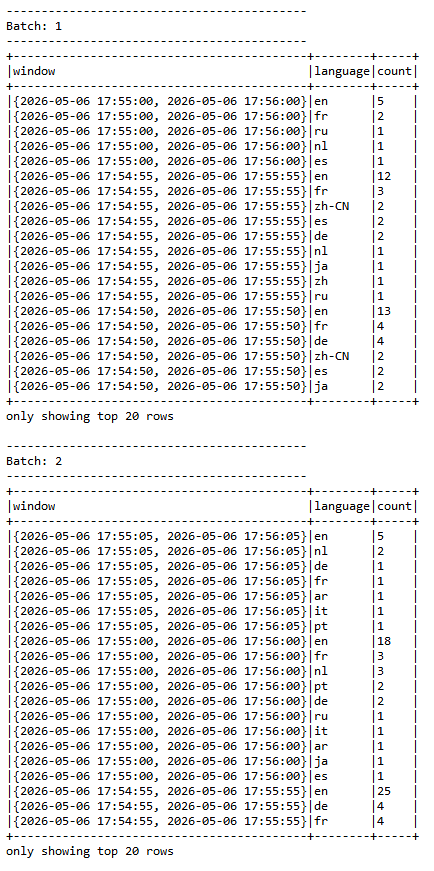
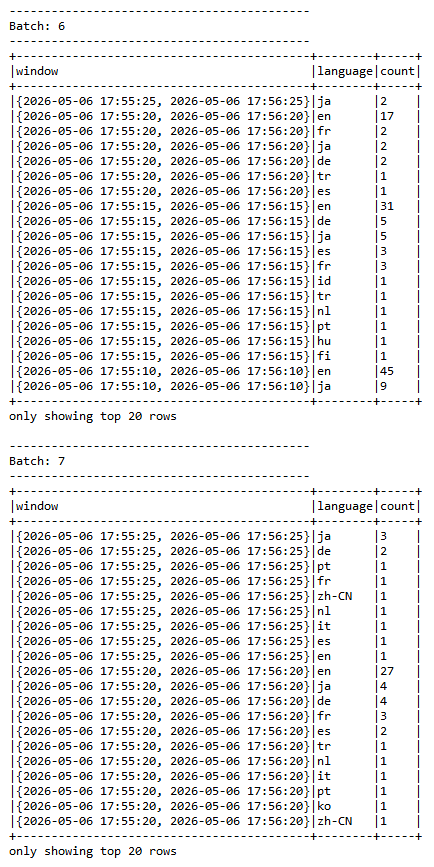


### Exercici 11.4: Unir Fluxos (1 punt)

En aquest darrer exercici, explorarem una característica molt interessant de Spark Streaming que et permet 
**[unir dos streams](https://downloads.apache.org/spark/docs/3.3.0/structured-streaming-programming-guide.html#stream-stream-joins)
i analitzar-los!**


Per simplificar les coses, ja et proporcionem dos fluxos de dades pre-agregats. 
El primer, que es troba al tema de Kafka **`mastodon_toots_original_domain`**, mostra el recompte de toots originals per a diverses instàncies de Mastodon (recorda que Mastodon és una federació d'instàncies) durant **una finestra fixa d'un minut**. 
El segon flux, al **`mastodon_toots_retoot_domain` topic**, presenta dades similars, però per als toots que són retweets (compartits) d'altres toots. Les dades emmagatzemades als temes de Kafka tenen la mateixa estructura en format JSON:

- Una estructura `window` amb dos elements de tipus `string`: `start` i `end` 
- Un component `string` anomenat `mastodon_instance` amb el topic.
- Un element de tipus `integer` anomenat `count` amb el nombre de toots realitzats en aquell domini en el rang de temps específic.

Donat que l'estructura de les dades és bastant senzilla, aquesta vegada **et demanem que la defineixis manualment**, en lloc d'usar el truc de batch. Un cop hagis configurat les estructures, **hauràs d'obrir un flux per a cada font de Kafka.** El pas següent és unir aquests fluxos. Volem que realitzis una **left join del flux de toots originals amb el flux de retweets**. Després de completar la unió, la teva sortida ha d'incloure:


- **`window`:** el rang de temps
- **`mastodon_instance`:** el domini de la instància de Mastodon
- **`original_count`:** nombre de toots originals publicats en aquell domini durant aquell rang de temps
- **`retweet_count`:** nombre de toots de retweets publicats en aquell domini durant aquell rang de temps

**TIP**: Realitzar una unió en línia de dos fluxos no és una tasca fàcil, i hi ha moltes restriccions que has de respectar. 
Llegeix acuradament [la documentació](https://downloads.apache.org/spark/docs/3.3.0/structured-streaming-programming-guide.html#stream-stream-joins)
i recorda que estem usant la versió 2.4.0. 
A més, recorda que estem realitzant **join over time**, i aquest és un component **clau**. 
Conceptes com els que has après sobre windows són fonamentals juntament amb conceptes com [watermarking](https://downloads.apache.org/spark/docs/3.3.0/structured-streaming-programming-guide.html#stream-stream-joins).
I recorda, **els modes de sortida són complicats** i has de triar-ne un que sigui adequat per a la feina que vols fer.


**En aquest exercici s’ha implementat una unió (join) entre dos fluxos de dades en temps real utilitzant Spark Structured Streaming. Els dos fluxos provenen de diferents topics de Kafka: un amb el nombre de toots originals i un altre amb el nombre de retweets, tots dos agregats per finestres de temps.**

**Primer s’ha definit manualment l’esquema de les dades JSON, que inclou una estructura de finestra (start, end), el domini (mastodon_instance) i el recompte (count) [[22]](https://blog.damavis.com/en/apache-spark-structured-streaming-practical-examples/) [[]](https://stackoverflow.com/questions/43284380/spark-structured-streaming-with-python?) [[23]](https://medium.com/@baljeetsethi3/spark-structured-streaming-b7135b77d3ea). A continuació, s’ha creat un streaming DataFrame per a cada topic de Kafka, on s’ha configurat l’opció startingOffsets a earliest en la lectura dels topics de Kafka per tal de processar totes les dades disponibles des de l’inici. Això permet llegir tots els missatges ja existents al topic en lloc de començar només pels nous esdeveniments que arribin després d’iniciar l’aplicació. Després s'ha parsejat el contingut i seleccionat les columnes necessàries de cada conjunt.**

**Per poder fer una unió temporal entre fluxos s’ha creat una columna de temps (event_time) a partir del camp start i s’ha aplicat un watermark de 2 minuts en ambdós fluxos. Això és necessari per limitar l’estat intern de Spark i permetre la gestió de dades que arriben amb retard (altres exemples utilitzen expr sumant un interval, però no podem importar la llibreria per limitacions de l'enunciat [[24]](https://stackoverflow.com/questions/75755861/left-outer-stream-stream-self-join-using-spark-structured-streaming-kafka?)).**

**La unió realitzada és de tipus left join, on el flux de toots originals és la taula esquerra. La condició de la unió es basa en la igualtat del domini (mastodon_instance) i una condició temporal sobre event_time.**

**Finalment, els resultats es mostren per consola utilitzant el mode append, perquè només volem mostrar els nous resultats a mesura que es processen els micro-batches del stream [[25]](https://downloads.apache.org/spark/docs/3.3.0/structured-streaming-programming-guide.html#stream-stream-joins). En aquest exercici, cada fila representa un resultat final per a una finestra de temps concreta, i un cop aquesta informació s’ha generat no es modifica.**

In [ ]:
import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql.types import StringType, StructType, StructField, IntegerType
from pyspark import SparkConf, SparkContext
from pyspark.sql.functions import from_json, col, window, to_timestamp, struct
from pyspark.sql import SparkSession
import org.apache.spark.sql.functions.expr

# Initialize Spark Context
conf = SparkConf()
conf.setMaster("local[*]")
sc = SparkContext(conf=conf)
sc.setLogLevel("ERROR")

# Initialize Spark Session for Structured Streaming
app_name = "activity3_4_aestanymac&nlopezlopez" # Replace with your Spark app name must include the username of the members of the group

spark = SparkSession \
    .builder \
    .appName(app_name) \
    .getOrCreate()

# Define schema for the incoming data
schema = StructType([
    StructField("window", StructType([
        StructField("start", StringType()),
        StructField("end", StringType())
    ])),
    StructField("mastodon_instance", StringType()),
    StructField("count", IntegerType())
])

# Define Kafka parameters
toots_original_topic = "mastodon_toots_original_domain"
toots_retoot_topic = "mastodon_toots_retoot_domain"
kafka_bootstrap_servers = "eimtcld3node1:9092" # Replace with your Kafka bootstrap servers

# Create streaming DataFrame by reading original toots data from Kafka
toots_original = spark \
    .readStream \
    .format("kafka") \
    .option("kafka.bootstrap.servers", kafka_bootstrap_servers) \
    .option("subscribe", toots_original_topic) \
    .option("startingOffsets", "earliest") \
    .load()

# Parse the value column as JSON and apply the infered schema. Then select the columns we need.
toots_original_df = toots_original \
    .select(from_json(col("value").cast("string"), schema).alias("json")) \
    .select(
        col("json.window.start").alias("start"),
        col("json.window.end").alias("end"),
        col("json.mastodon_instance"),
        col("json.count").alias("original_count")
    ) \
    .withColumn("event_time", to_timestamp(col("start"))) \
    .withWatermark("event_time", "2 minutes")

# Create streaming DataFrame by reading retoots data from Kafka
toots_original = spark \
    .readStream \
    .format("kafka") \
    .option("kafka.bootstrap.servers", kafka_bootstrap_servers) \
    .option("subscribe", toots_retoot_topic) \
    .option("startingOffsets", "earliest") \
    .load()

# Parse the value column as JSON and apply the infered schema. Then select the columns we need.
toots_retoot_df = toots_retoot \
    .select(from_json(col("value").cast("string"), schema).alias("json")) \
    .select(
        col("json.window.start").alias("start"),
        col("json.window.end").alias("end"),
        col("json.mastodon_instance"),
        col("json.count").alias("retweet_count")
    ) \
    .withColumn("event_time", to_timestamp(col("start"))) \
    .withWatermark("event_time", "2 minutes")

# Join the two streams
toots_join_df = toots_original_df.alias("o").join(
    toots_retoot_df.alias("r"),
    (
        (col("o.mastodon_instance") == col("r.mastodon_instance")) &
        (col("r.event_time") >= col("o.event_time")) &
        (col("r.event_time") <= col("o.event_time"))
    ),
    "left"
).select(
    struct(
        col("o.start"),
        col("o.end")
    ).alias("window"),
    col("o.mastodon_instance"),
    col("o.original_count"),
    col("r.retweet_count")
)
try:
    # Start running the query that prints the running counts to the console
    query = toots_join_df \
        .writeStream \
        .outputMode("append") \
        .format("console") \
        .option("truncate", "false") \
        .trigger(processingTime="10 seconds")\
        .option("numRows", 100) \
        .start()

    query.awaitTermination()
except KeyboardInterrupt:
    query.stop()
    spark.stop()
    sc.stop()

**El codi anterior tambe s'ha executat mitjançant:**



**I s'ha obtingut:**

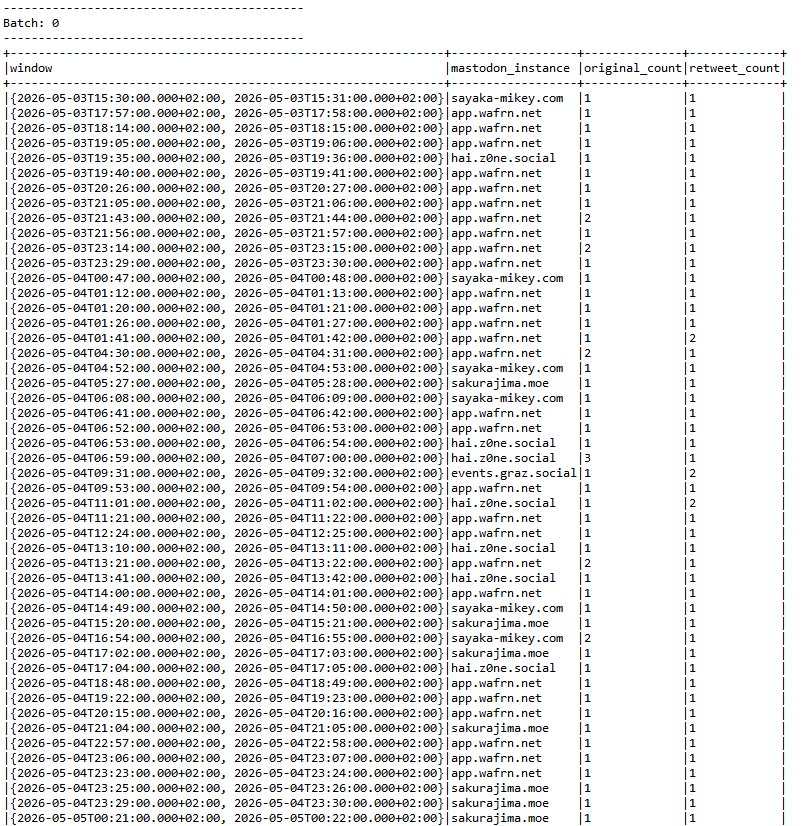

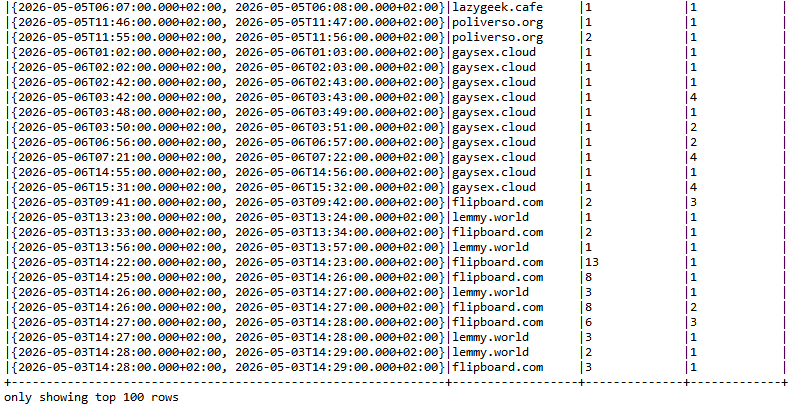

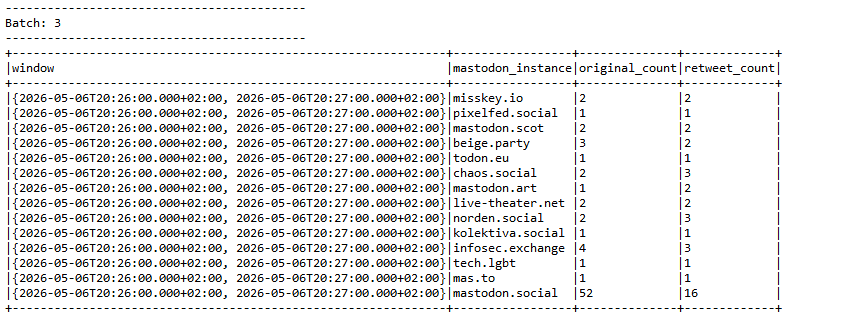

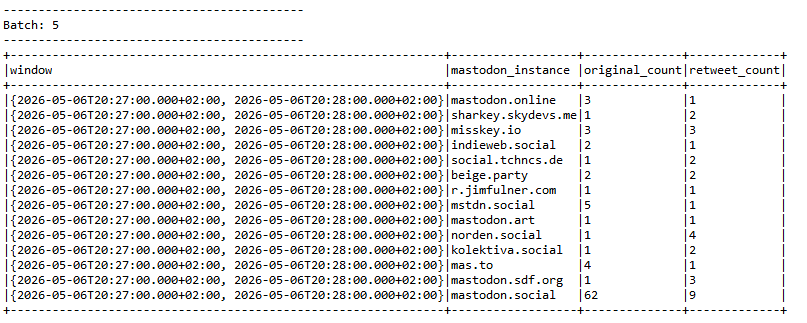


### **Exercici 12**: Preguntes teòriques (*2.5 punts*)

Durant l'entrevista final amb cada grup, que es realitzarà mitjançant videotrucada, es revisarà breument la pràctica realitzada.

En l'última part de l'entrevista es plantejaran 4 preguntes teòriques relacionades amb els continguts de la pràctica i del mòdul 5.

- Cada pregunta tindrà una puntuació de 0,625 punts.

- Les preguntes es respondran oralment durant l'entrevista.

- Es valorarà la comprensió dels conceptes teòrics i la capacitat d'explicar-los amb claredat.

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()